## Setup

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import missingno as msno
import shap



In [3]:
HERE = os.path.abspath('')      
DATA_DIR = os.path.join(HERE, "data")
PATH = os.path.join(DATA_DIR, "ai_productivity_dataset_final.csv")

In [4]:
df_productivity = pd.read_csv(PATH)


In [5]:
print("Dataset shape:", df_productivity.shape)

print("\n--- INFO ---")
df_productivity.info()

print("\n--- DESCRIPTIVE STATISTICS  ---")
display(df_productivity.describe())

print("\n--- FIRST ROWS ---")
display(df_productivity.head())

print("\n--- COLUMNS ---")
print(df_productivity.columns.tolist())

Dataset shape: (3248, 34)

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 3248 entries, 0 to 3247
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   task_id                3248 non-null   str    
 1   client                 3248 non-null   str    
 2   project_id             3248 non-null   str    
 3   client_tier            3248 non-null   str    
 4   team                   3248 non-null   str    
 5   task_type              3248 non-null   str    
 6   seniority              3248 non-null   str    
 7   task_complexity_score  3248 non-null   int64  
 8   brief_quality_score    3179 non-null   float64
 9   deadline_pressure      3248 non-null   str    
 10  scope_change_flag      3248 non-null   int64  
 11  pricing_model          3248 non-null   str    
 12  created_at             3248 non-null   str    
 13  delivered_at           3210 non-null   str    
 14  sla_days               3212

,task_complexity_score,brief_quality_score,scope_change_flag,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,revisions,errors,rework_hours,outcome_score,revenue,cost,profit
count,3248.000000,3179.000000,3248.000000,3212.000000,3248.000000,3248.00000,3166.000000,3104.000000,3248.000000,3248.000000,3176.000000,3115.000000,3248.000000,3248.000000,3248.000000
mean,2.868842,3.183391,0.139163,5.012765,0.398091,13.05551,8.431563,0.361717,3.007697,1.014163,2.437543,68.856918,1120.571260,771.308146,349.263114
std,1.196459,1.211712,0.346169,2.520330,0.489580,11.55750,4.783216,0.199391,1.804829,1.042868,2.911421,12.642211,841.649433,584.269354,888.072715
min,1.000000,1.000000,0.000000,2.000000,0.000000,0.02000,-1.900000,0.000000,0.000000,0.000000,0.000000,9.000000,45.000000,77.850000,-8510.549511
25%,2.000000,2.000000,0.000000,3.000000,0.000000,7.91000,5.080000,0.200000,2.000000,0.000000,1.110000,60.870000,646.312500,440.805000,-2.610000
50%,3.000000,3.000000,0.000000,5.000000,0.000000,11.11500,7.535000,0.340000,3.000000,1.000000,1.810000,69.400000,966.430000,649.065000,254.645000
75%,4.000000,4.000000,0.000000,7.000000,1.000000,15.34500,10.687500,0.500000,4.000000,2.000000,2.950000,77.610000,1364.700000,941.145000,590.400000
max,5.000000,5.000000,1.000000,10.000000,1.000000,263.60018,47.020000,0.930000,11.000000,7.000000,57.517012,100.000000,14927.204324,9409.639511,14006.644324



--- FIRST ROWS ---


,task_id,client,project_id,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,...,revenue,cost,profit,created_by,updated_at,task_status,workflow_stage,jira_ticket,legacy_ai_flag,content_version
0,T00000,Client_F,P038,mid,Content,report,junior,2,3.0,high,...,498.11,346.17,151.94,user_096,2025-11-28,review,finalized,JIRA-49014,true,v1
1,T00001,Client_H,P028,low,Paid Media,release,junior,1,2.0,medium,...,847.01,343.18,503.83,user_058,2026-01-26,delivered,client_review,JIRA-84793,false,v1
2,T00002,Client_D,P009,low,Design,dev,junior,3,4.0,medium,...,1374.07,365.02,1009.05,user_074,2025-09-17,in_progress,qa,JIRA-42485,true,v2
3,T00003,Client_E,P023,mid,Content,design,mid,3,2.0,low,...,2379.11,1514.73,864.38,user_011,2025-11-12,in_progress,briefing,JIRA-53111,false,v1
4,T00004,Client_C,P014,low,Design,article,senior,2,5.0,low,...,709.95,335.27,374.68,user_007,2026-05-09,review,execution,JIRA-86006,true,v2



--- COLUMNS ---
['task_id', 'client', 'project_id', 'client_tier', 'team', 'task_type', 'seniority', 'task_complexity_score', 'brief_quality_score', 'deadline_pressure', 'scope_change_flag', 'pricing_model', 'created_at', 'delivered_at', 'sla_days', 'sla_breach', 'hours_spent', 'billable_hours', 'ai_usage_pct', 'ai_assisted', 'revisions', 'errors', 'rework_hours', 'outcome_score', 'revenue', 'cost', 'profit', 'created_by', 'updated_at', 'task_status', 'workflow_stage', 'jira_ticket', 'legacy_ai_flag', 'content_version']


In [6]:
num_cols = df_productivity.select_dtypes(include=[np.number]).columns.tolist()

cat_cols = df_productivity.select_dtypes(include=['object', 'string']).columns.tolist()

print("Numerical columns:", num_cols)
print("\nCategorical columns:", cat_cols)

Numerical columns: ['task_complexity_score', 'brief_quality_score', 'scope_change_flag', 'sla_days', 'sla_breach', 'hours_spent', 'billable_hours', 'ai_usage_pct', 'revisions', 'errors', 'rework_hours', 'outcome_score', 'revenue', 'cost', 'profit']

Categorical columns: ['task_id', 'client', 'project_id', 'client_tier', 'team', 'task_type', 'seniority', 'deadline_pressure', 'pricing_model', 'created_at', 'delivered_at', 'created_by', 'updated_at', 'task_status', 'workflow_stage', 'jira_ticket', 'legacy_ai_flag', 'content_version']


# Duplicates check

In [7]:
duplicates = df_productivity.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [8]:
dup_count = df_productivity.duplicated(subset='task_id').sum()

print(f"Number of duplicates (task_id): {dup_count}")

Number of duplicates (task_id): 48


In [9]:
df_productivity['updated_at'] = pd.to_datetime(df_productivity['updated_at'])

df_productivity = (
    df_productivity
    .sort_values(['task_id', 'updated_at'])
    .groupby('task_id')
    .tail(1)
    .reset_index(drop=True)
)


In [10]:
dup_count = df_productivity.duplicated(subset='task_id').sum()

print(f"Number of duplicates (task_id): {dup_count}")

Number of duplicates (task_id): 0


# Team normalization

In [11]:
df_productivity['team'] = df_productivity['team'].str.strip()


print('Teams BEFORE:', sorted(df_productivity['team'].dropna().unique()))


df_productivity['team'] = df_productivity['team'].str.lower()

team_map = {
    'seo': 'SEO',
    'media': 'Media',
    'paid media': 'Media',
    'content': 'Content',
    'contennt': 'Content',
    'design': 'Design',
    'desgn': 'Design'
}

df_productivity['team'] = df_productivity['team'].replace(team_map)


print('Teams AFTER:', sorted(df_productivity['team'].dropna().unique()))


print('\nDistribution:')
print(df_productivity['team'].value_counts(dropna=False))

Teams BEFORE: ['CONTENT', 'Contennt', 'Content', 'DESIGN', 'Desgn', 'Design', 'MEDIA', 'Media', 'Paid Media', 'SEO', 'content', 'design', 'media', 'seo']
Teams AFTER: ['Content', 'Design', 'Media', 'SEO']

Distribution:
team
Content    827
Media      805
Design     790
SEO        778
Name: count, dtype: int64


# Date Parsing

In [12]:
date_cols = ['created_at', 'delivered_at']
for col in date_cols:
    df_productivity[col] = pd.to_datetime(df_productivity[col], errors='coerce')
    n_nat = df_productivity[col].isna().sum()
    print(f"{col}: {n_nat} values NaT after the conversion")



df_productivity['duration_days'] = (
    df_productivity['delivered_at'] - df_productivity['created_at']
).dt.days


mask_neg = df_productivity['duration_days'] < 0
neg_count = mask_neg.sum()
print(f"\nNegative durations found: {neg_count}")


if neg_count > 0:
    print(df_productivity.loc[mask_neg, ['task_id', 'created_at', 'delivered_at', 'duration_days']].head())
    df_productivity.loc[mask_neg, 'duration_days'] = np.nan


print("\nduration_days:")
print(df_productivity['duration_days'].describe().round(1))

created_at: 0 values NaT after the conversion
delivered_at: 38 values NaT after the conversion

Negative durations found: 14
     task_id created_at delivered_at  duration_days
89    T00089 2025-10-06   2025-10-05           -1.0
403   T00403 2026-02-09   2026-02-08           -1.0
878   T00878 2026-03-29   2026-03-26           -3.0
1083  T01083 2025-11-13   2025-11-12           -1.0
1112  T01112 2025-12-06   2025-12-05           -1.0

duration_days:
count    3148.0
mean        4.5
std         1.8
min         0.0
25%         3.0
50%         5.0
75%         6.0
max        10.0
Name: duration_days, dtype: float64


## Legacy AI Flag Cleaning


In [13]:
print("Before cleaning:")
print(df_productivity['legacy_ai_flag'].value_counts(dropna=False))

df_productivity['legacy_ai_flag'] = (
    df_productivity['legacy_ai_flag']
    .astype(str)
    .str.strip()
    .str.lower()
)


df_productivity['legacy_ai_flag'] = df_productivity['legacy_ai_flag'].replace('unknown', np.nan)


df_productivity['legacy_ai_flag'] = df_productivity['legacy_ai_flag'].map({
    'true': 1,
    'false': 0
})

print("\nAfter cleaning:")
print(df_productivity['legacy_ai_flag'].value_counts(dropna=False))


ai_indicator = (df_productivity['ai_usage_pct'] > 0).astype(int)

correlation = ai_indicator.corr(df_productivity['legacy_ai_flag'])
print(f"\nCorrelation with AI usage indicator: {correlation:.3f}")

Before cleaning:
legacy_ai_flag
false      1436
true       1427
unknown     337
Name: count, dtype: int64

After cleaning:
legacy_ai_flag
0.0    1436
1.0    1427
NaN     337
Name: count, dtype: int64

Correlation with AI usage indicator: -0.014


### Missing value analysis

Before imputing, we check how many NaN values exist per column and whether
the rows with missing `ai_usage_pct` differ from the rest of the dataset.

In [14]:
missing = df_productivity.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

legacy_ai_flag         337
jira_ticket            331
ai_usage_pct           143
outcome_score          132
billable_hours          81
rework_hours            72
brief_quality_score     68
duration_days           52
delivered_at            38
sla_days                34
dtype: int64

In [15]:
missing_pct = (df_productivity.isnull().sum() / len(df_productivity) * 100)
missing_pct.sort_values(ascending=False)

legacy_ai_flag           10.53125
jira_ticket              10.34375
ai_usage_pct              4.46875
outcome_score             4.12500
billable_hours            2.53125
rework_hours              2.25000
brief_quality_score       2.12500
duration_days             1.62500
delivered_at              1.18750
sla_days                  1.06250
task_complexity_score     0.00000
team                      0.00000
content_version           0.00000
project_id                0.00000
client_tier               0.00000
workflow_stage            0.00000
task_status               0.00000
updated_at                0.00000
created_by                0.00000
profit                    0.00000
cost                      0.00000
revenue                   0.00000
errors                    0.00000
task_type                 0.00000
deadline_pressure         0.00000
revisions                 0.00000
ai_assisted               0.00000
seniority                 0.00000
client                    0.00000
hours_spent   

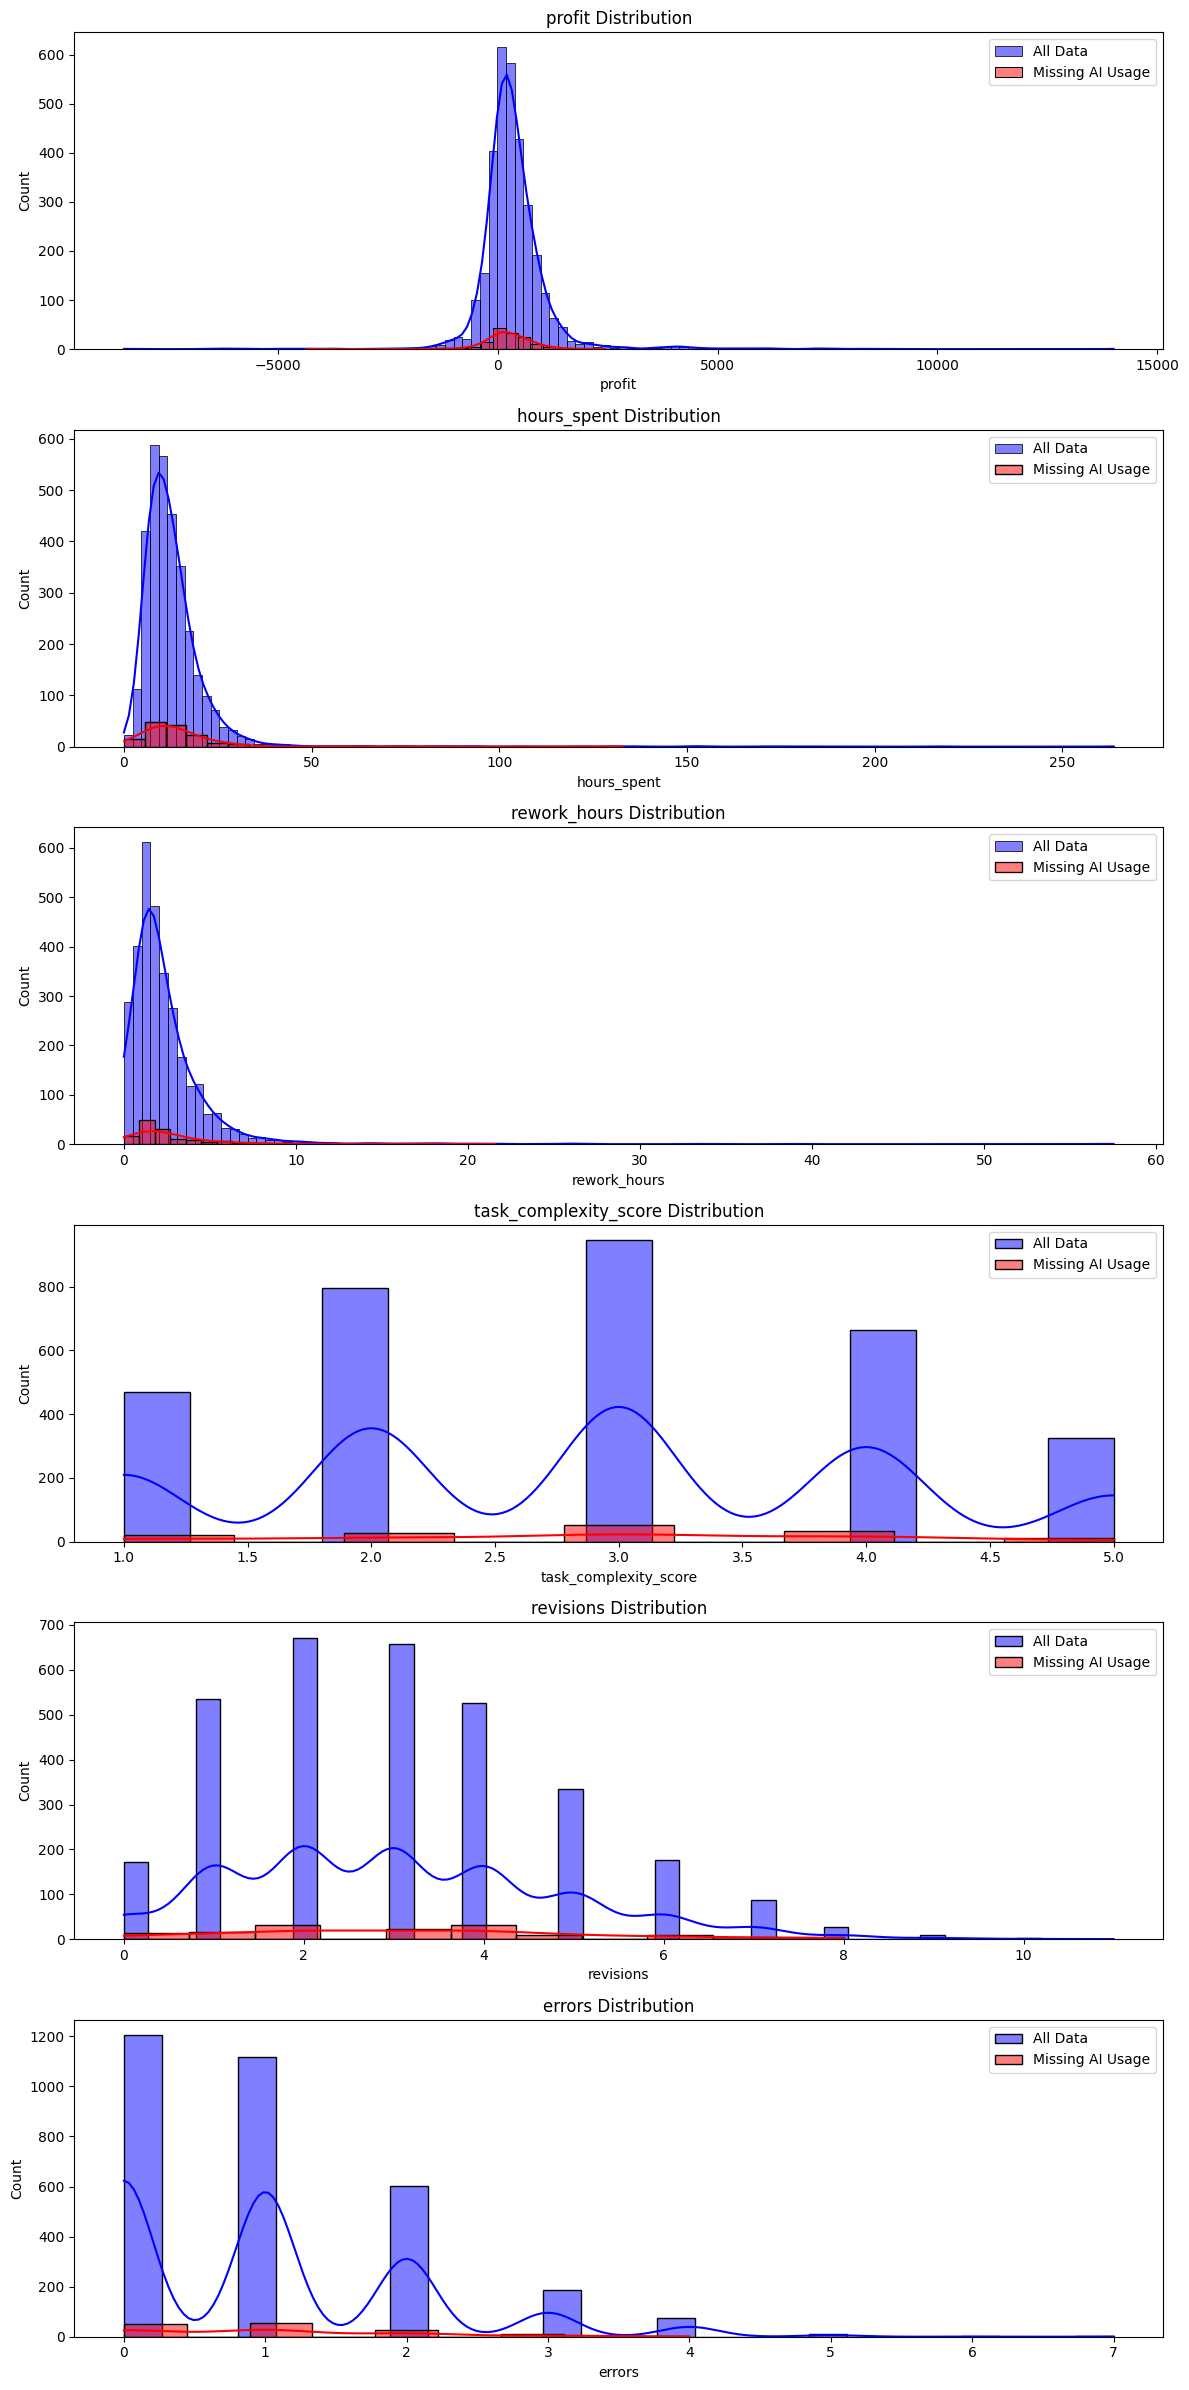

In [16]:
missing_ai_rows = df_productivity[df_productivity['ai_usage_pct'].isnull()]


columns = [
    'profit',
    'hours_spent',
    'rework_hours',
    'task_complexity_score',
    'revisions',
    'errors'
]


fig, axes = plt.subplots(len(columns), 1, figsize=(12, 4 * len(columns)))


for i, column in enumerate(columns):
    
    if column in df_productivity.select_dtypes(include=['int64', 'float64']).columns:
        sns.histplot(df_productivity[column], ax=axes[i], kde=True, color='blue', label='All Data')
        sns.histplot(missing_ai_rows[column], ax=axes[i], kde=True, color='red', label='Missing AI Usage')
    else:
        sns.countplot(data=df_productivity, x=column, ax=axes[i], color='blue', label='All Data')
        sns.countplot(data=missing_ai_rows, x=column, ax=axes[i], color='red', label='Missing AI Usage')
    
    axes[i].set_title(f'{column} Distribution')
    axes[i].set_xlabel(column)
    axes[i].legend()


plt.tight_layout()
plt.show()

<Axes: >

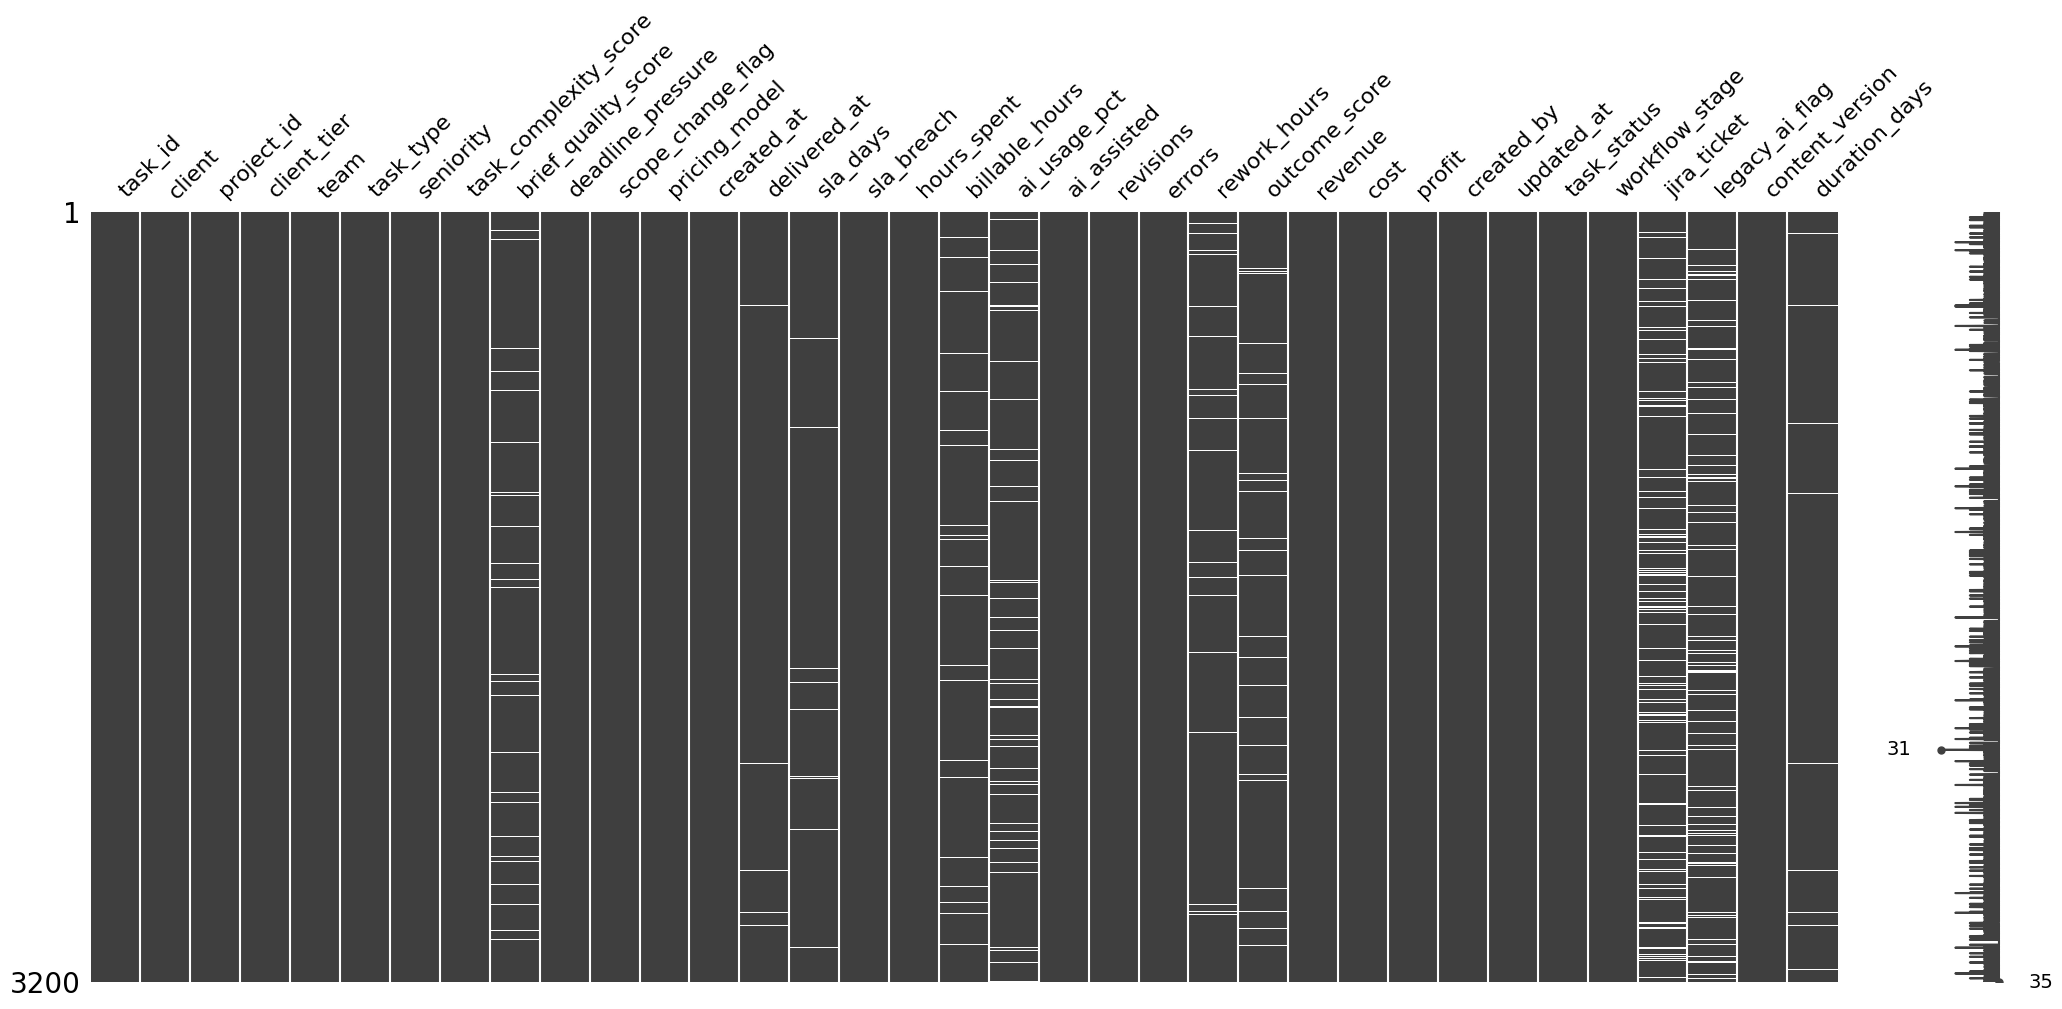

In [17]:
msno.matrix(df_productivity)

**taking care of nans**

In [18]:
df_productivity = df_productivity.drop(columns=['jira_ticket'], errors='ignore')



df_productivity['ai_usage_pct'] = df_productivity['ai_usage_pct'].fillna(
    df_productivity['ai_usage_pct'].median()
)

df_productivity['outcome_score'] = df_productivity['outcome_score'].fillna(
    df_productivity['outcome_score'].median()
)

df_productivity['brief_quality_score'] = df_productivity['brief_quality_score'].fillna(
    df_productivity['brief_quality_score'].median()
)

df_productivity['sla_days'] = df_productivity['sla_days'].fillna(
    df_productivity['sla_days'].median()
)



mask = df_productivity['billable_hours'].isna()

df_productivity.loc[mask, 'billable_hours'] = (
    df_productivity.loc[mask, 'hours_spent'] * 0.85
)



df_productivity['rework_hours'] = df_productivity['rework_hours'].fillna(
    df_productivity['rework_hours'].median()
)


remaining = df_productivity.isnull().sum()
remaining = remaining[remaining > 0]

print("\nRemaining missing values:")
print(remaining)


Remaining missing values:
delivered_at       38
legacy_ai_flag    337
duration_days      52
dtype: int64


### Outlier detection and treatment

We apply IQR × 3 to identify extreme values in the financial columns,
then visualize distributions before and after to verify the effect.


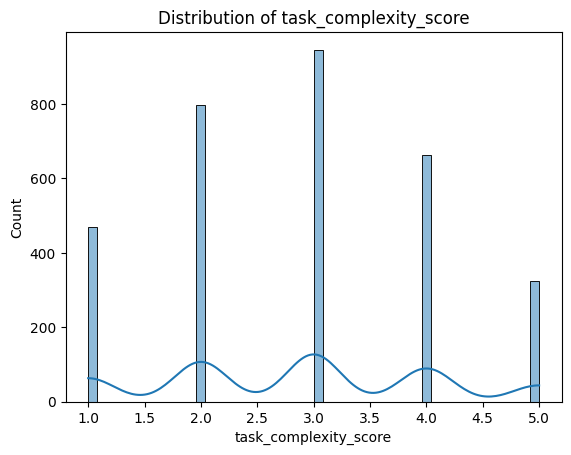

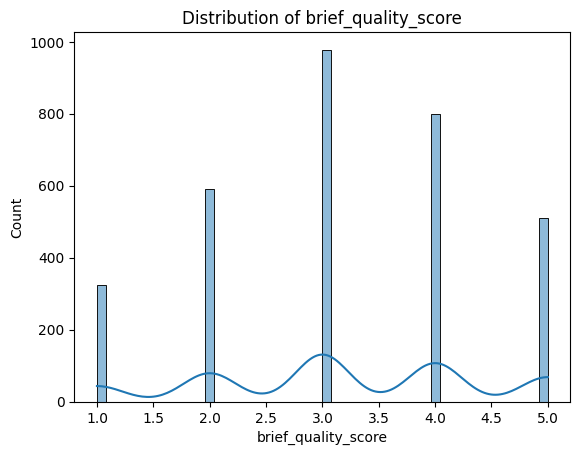

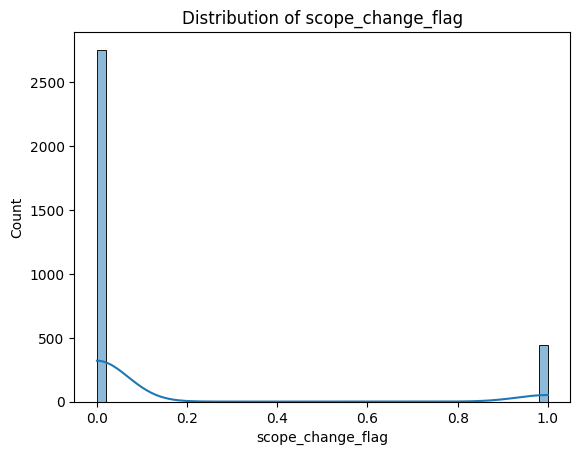

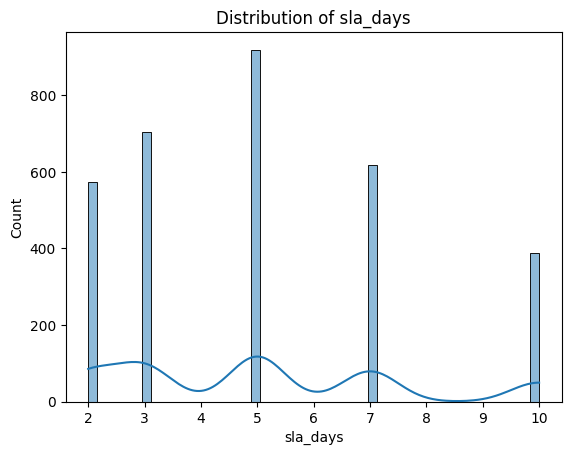

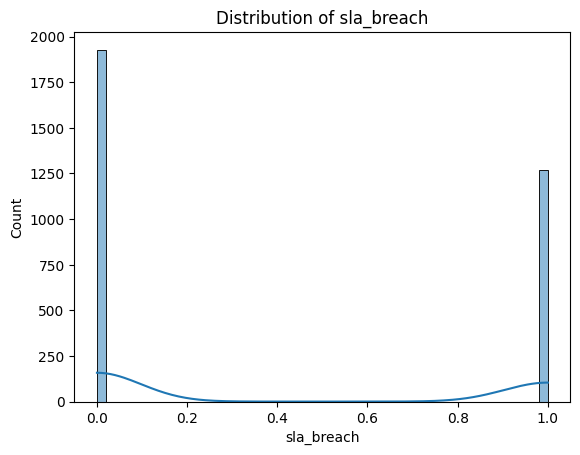

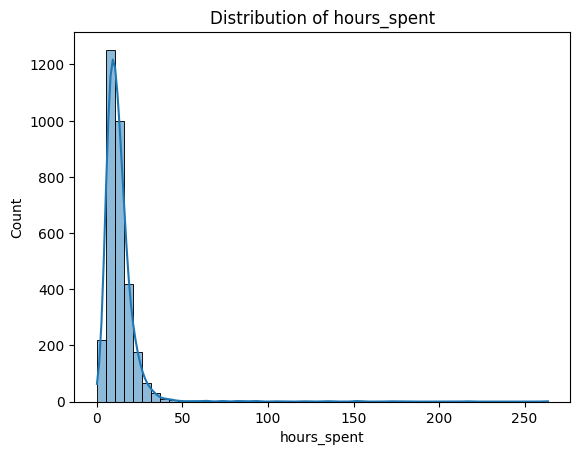

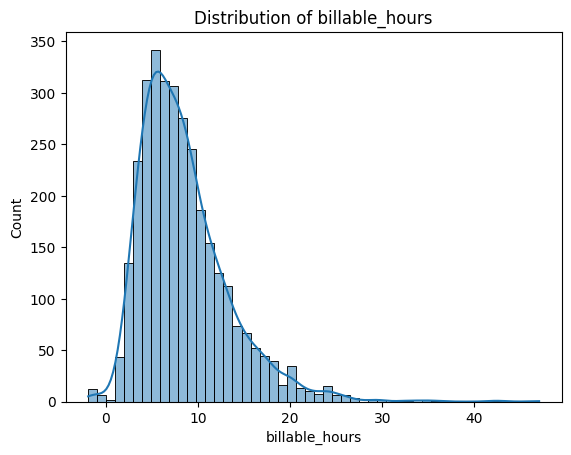

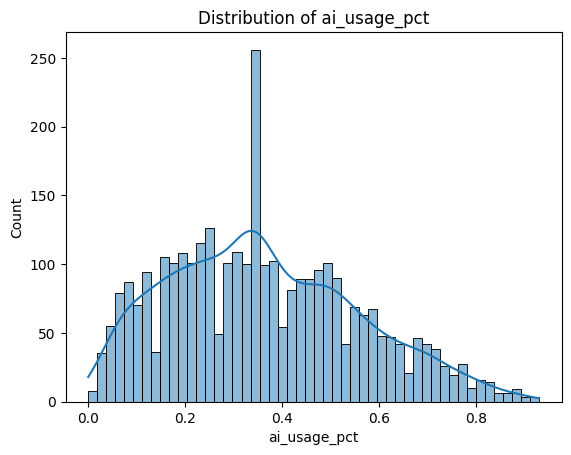

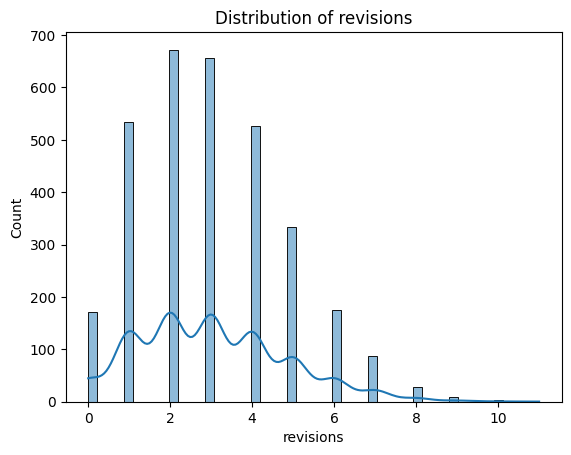

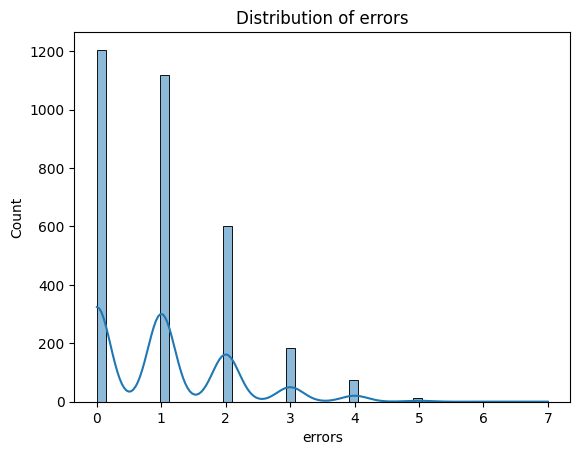

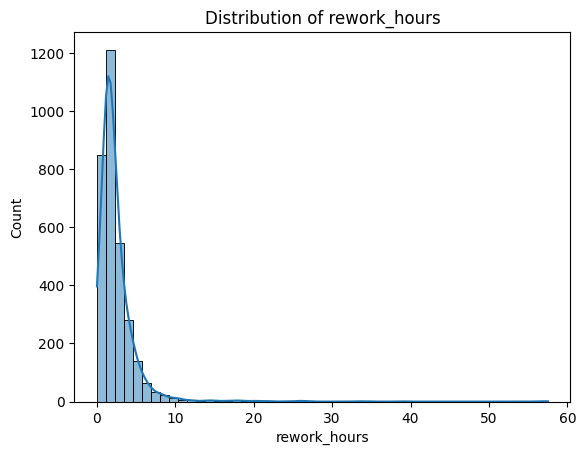

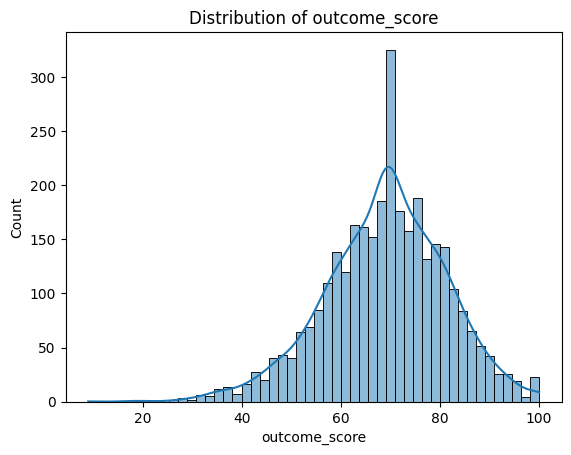

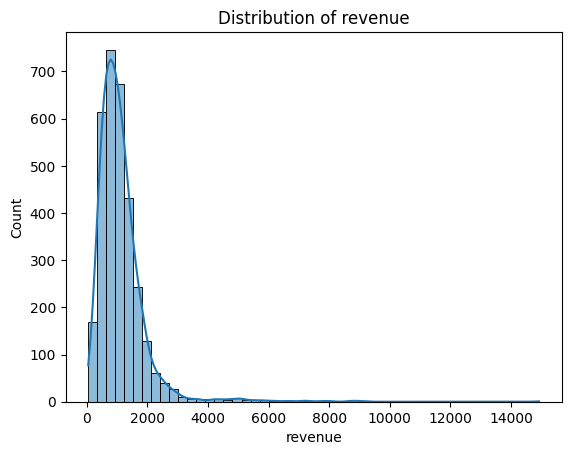

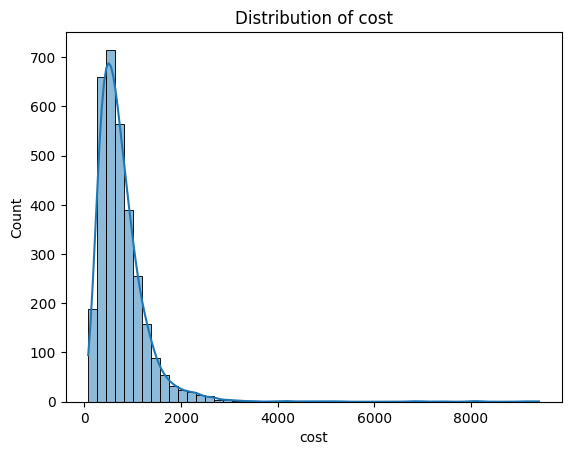

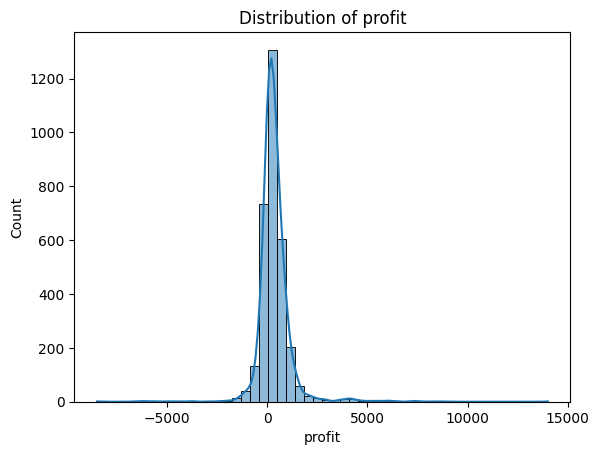

In [19]:
for col in num_cols:
    plt.figure()
    sns.histplot(df_productivity[col], bins=50, kde=True)
    plt.title(f'Distribution of {col}')


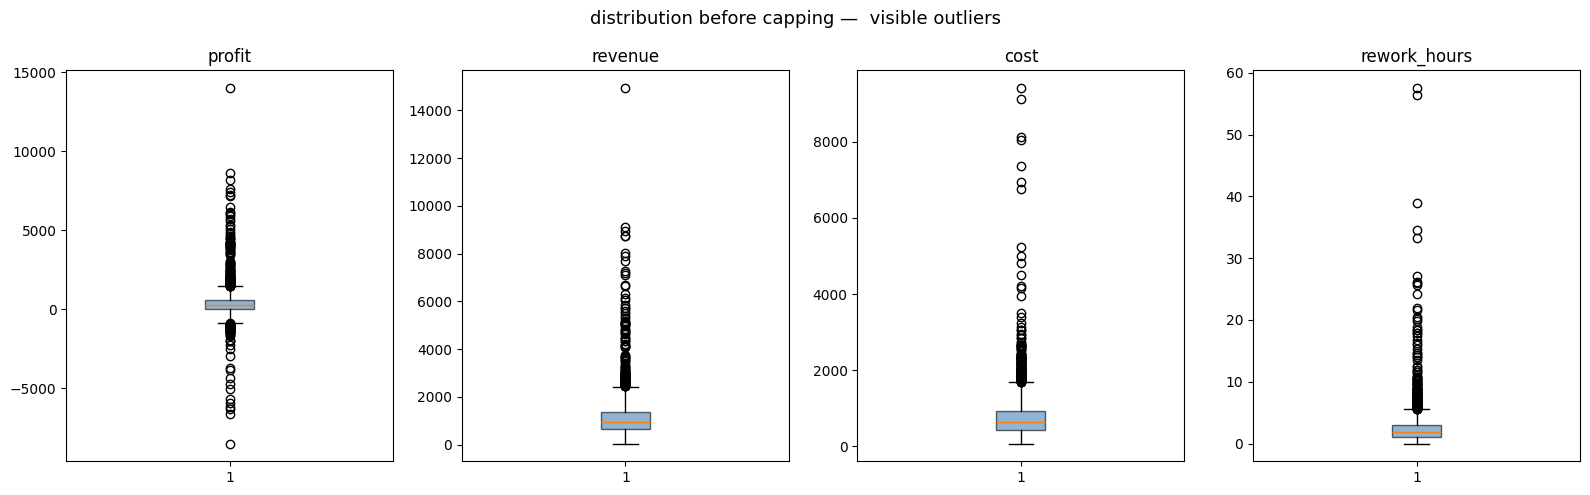

estreme outlier (IQR × 3):



In [20]:
cap_cols = ['profit', 'revenue', 'cost', 'rework_hours']

fig, axes = plt.subplots(1, len(cap_cols), figsize=(16, 5))
for i, col in enumerate(cap_cols):
    axes[i].boxplot(df_productivity[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel('')

plt.suptitle('distribution before capping —  visible outliers', fontsize=13)
plt.tight_layout()
plt.show()

print("estreme outlier (IQR × 3):\n")

In [21]:
for col in cap_cols:
    Q1 = df_productivity[col].quantile(0.25)
    Q3 = df_productivity[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    n_out = ((df_productivity[col] < lower) | 
             (df_productivity[col] > upper)).sum()
    pct = n_out / len(df_productivity) * 100
    print(f"  {col:<15} lower={lower:>8.2f}  upper={upper:>8.2f}  "
          f"outliers={n_out} ({pct:.1f}%)")



  profit          lower=-1777.78  upper= 2365.62  outliers=79 (2.5%)
  revenue         lower=-1510.15  upper= 3521.39  outliers=54 (1.7%)
  cost            lower=-1067.79  upper= 2447.60  outliers=38 (1.2%)
  rework_hours    lower=   -4.28  upper=    8.32  outliers=71 (2.2%)


In [22]:
def cap_iqr(series, k=3):
    q1    = series.quantile(0.25)
    q3    = series.quantile(0.75)
    iqr   = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    n_capped = ((series < lower) | (series > upper)).sum()
    return series.clip(lower, upper), n_capped

print("\nCapping applicato:\n")
for col in cap_cols:
    if col in df_productivity.columns:
        df_productivity[col], n = cap_iqr(df_productivity[col])
        print(f"  {col:<15} {n} capped values")


Capping applicato:

  profit          79 capped values
  revenue         54 capped values
  cost            38 capped values
  rework_hours    71 capped values



 Final shape: (3200, 34)


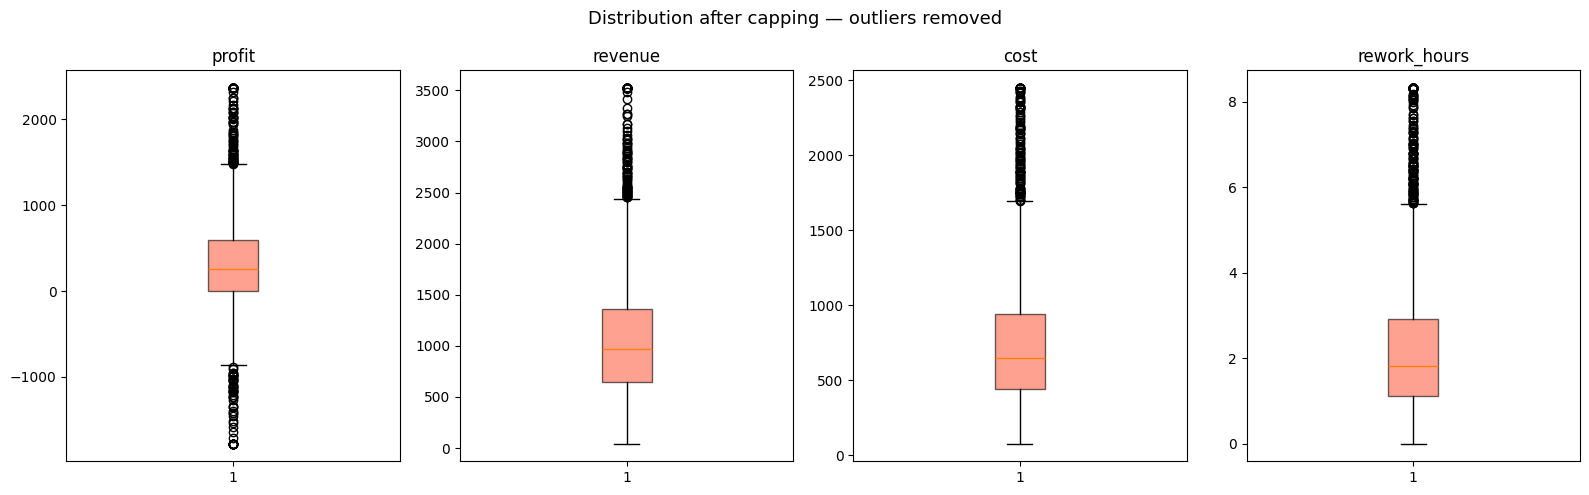

In [23]:
fig, axes = plt.subplots(1, len(cap_cols), figsize=(16, 5))
for i, col in enumerate(cap_cols):
    axes[i].boxplot(df_productivity[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='tomato', alpha=0.6))
    axes[i].set_title(f'{col}', fontsize=12)

plt.suptitle('Distribution after capping — outliers removed', fontsize=13)
plt.tight_layout()


print(f"\n Final shape: {df_productivity.shape}")

## **EDA BASE**

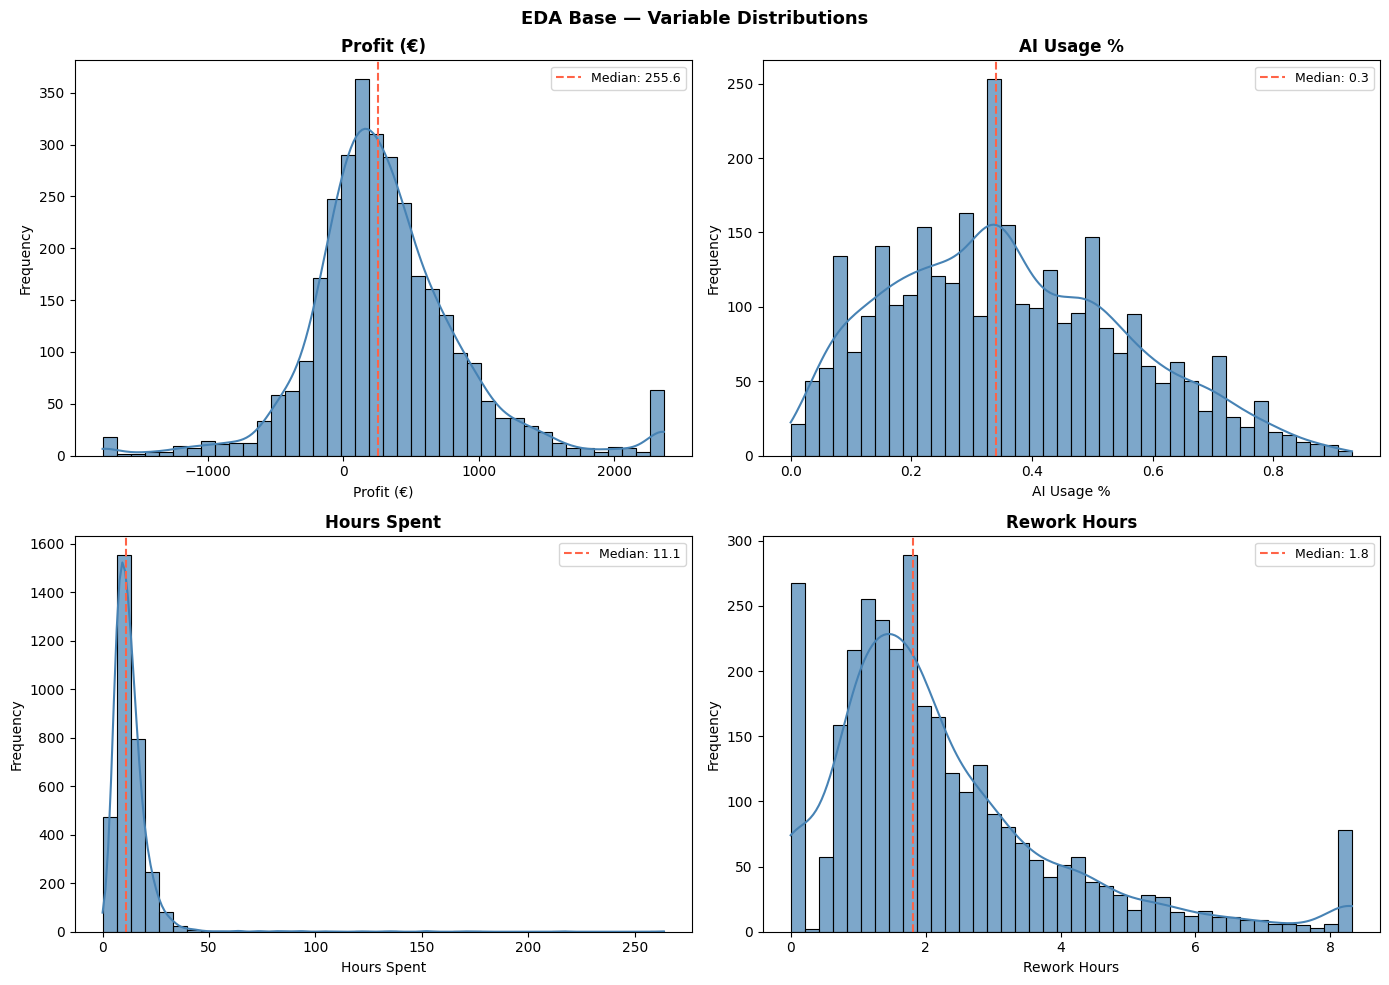

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA Base — Variable Distributions', fontsize=13, fontweight='bold')

vars_plot = [
    ('profit',       'Profit (€)'),
    ('ai_usage_pct', 'AI Usage %'),
    ('hours_spent',  'Hours Spent'),
    ('rework_hours', 'Rework Hours'),
]

for ax, (col, label) in zip(axes.flatten(), vars_plot):
    sns.histplot(df_productivity[col].dropna(), bins=40, kde=True,
                 color='steelblue', alpha=0.7, ax=ax)
    
    med = df_productivity[col].median()
    ax.axvline(med, color='tomato', linestyle='--', linewidth=1.5,
               label=f'Median: {med:.1f}')
    
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.tight_layout()


In [25]:
key_vars = [
    'profit', 'ai_usage_pct', 'hours_spent',
    'rework_hours', 'outcome_score', 'revenue'
]

stats_df = pd.DataFrame({
    'mean':     df_productivity[key_vars].mean().round(2),
    'median':   df_productivity[key_vars].median().round(2),
    'std':      df_productivity[key_vars].std().round(2),
    'skewness': df_productivity[key_vars].skew().round(3),
})

print("\n=== Descriptive statistics ===\n")
print(stats_df.to_string())

print("\nVariables with |skewness| > 1:")
print(stats_df[stats_df['skewness'].abs() > 1].index.tolist())


=== Descriptive statistics ===

                  mean  median     std  skewness
profit          321.39  255.60  591.02     0.648
ai_usage_pct      0.36    0.34    0.19     0.396
hours_spent      13.02   11.10   11.42     9.954
rework_hours      2.26    1.81    1.78     1.475
outcome_score    68.90   69.40   12.35    -0.338
revenue        1083.79  966.04  628.68     1.493

Variables with |skewness| > 1:
['hours_spent', 'rework_hours', 'revenue']


In [26]:
print("\nSkewness:")
skew_cols = ['profit', 'ai_usage_pct', 'hours_spent', 'rework_hours']
print(df_productivity[skew_cols].skew())


Skewness:
profit          0.647854
ai_usage_pct    0.395837
hours_spent     9.953660
rework_hours    1.474618
dtype: float64


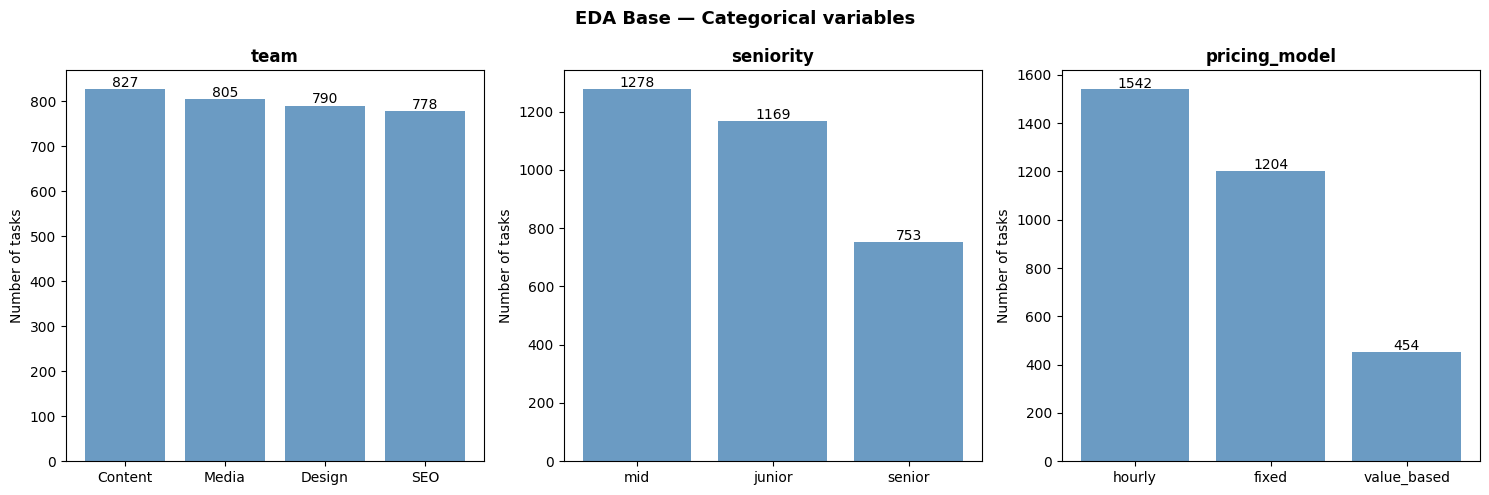

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('EDA Base — Categorical variables', fontsize=13, fontweight='bold')

for ax, col in zip(axes, ['team', 'seniority', 'pricing_model']):
    counts = df_productivity[col].value_counts()
    
    ax.bar(counts.index, counts.values, color='steelblue', alpha=0.8, edgecolor='none')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Number of tasks')
    
    for i, v in enumerate(counts.values):
        ax.text(i, v + 5, str(v), ha='center', fontsize=10)

plt.tight_layout()


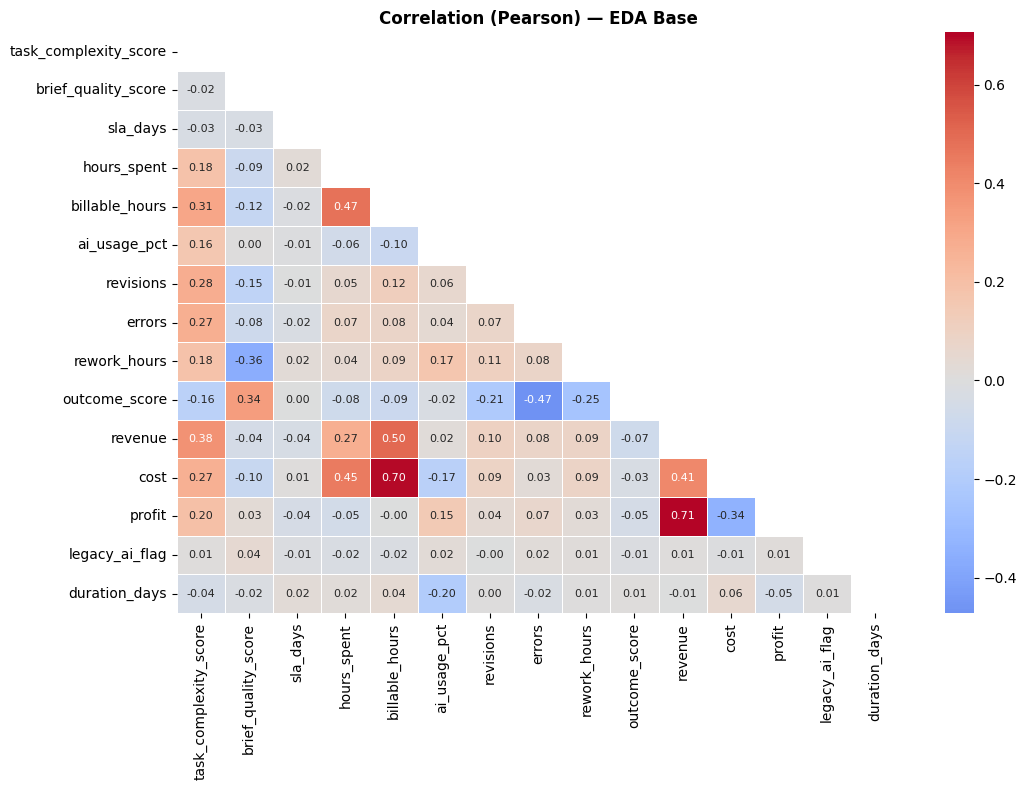

In [28]:

numeric = df_productivity.select_dtypes(include=[np.number])
exclude = ['scope_change_flag', 'sla_breach']
numeric = numeric.drop(columns=[c for c in exclude if c in numeric.columns])

corr = numeric.corr(method='pearson')
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.4,
            annot_kws={'size': 8})

plt.title('Correlation (Pearson) — EDA Base', fontweight='bold')
plt.tight_layout()
plt.show()

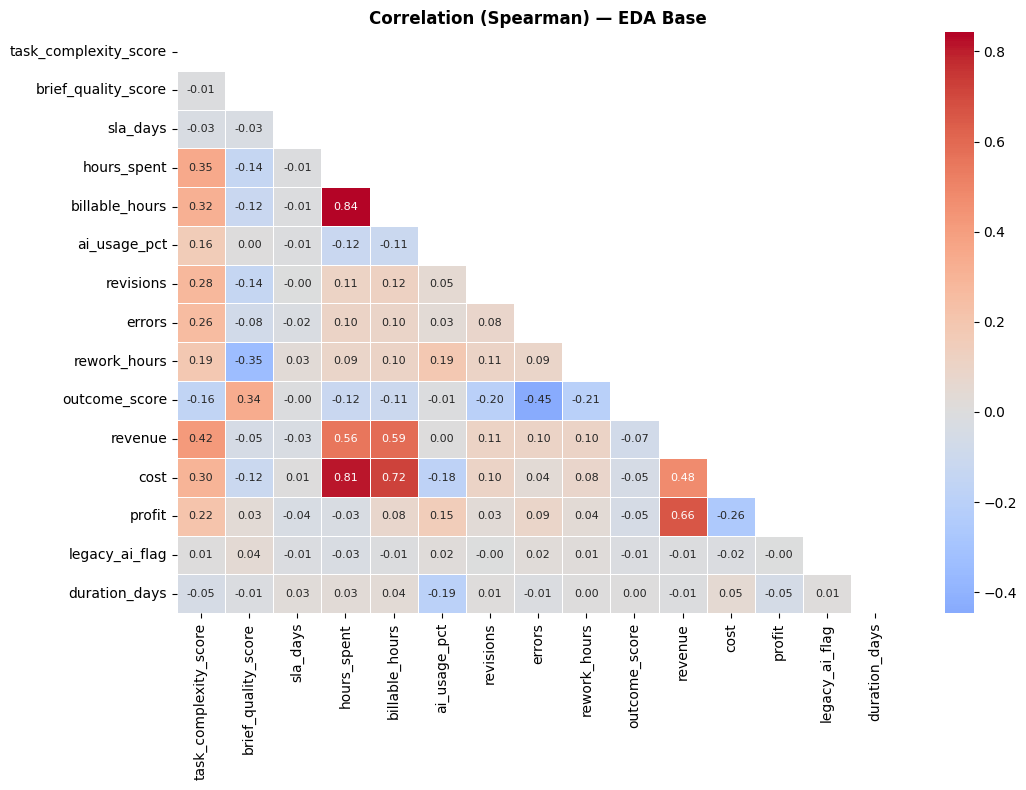

In [29]:
numeric = df_productivity.select_dtypes(include=[np.number])
exclude = ['scope_change_flag', 'sla_breach']
numeric = numeric.drop(columns=[c for c in exclude if c in numeric.columns])

corr = numeric.corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.4,
            annot_kws={'size': 8})

plt.title('Correlation (Spearman) — EDA Base', fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
print("\nKey Statistics:")
print(df_productivity[[
    'profit',
    'ai_usage_pct',
    'hours_spent',
    'rework_hours'
]].describe())


Key Statistics:
            profit  ai_usage_pct  hours_spent  rework_hours
count  3200.000000   3200.000000  3200.000000   3200.000000
mean    321.389776      0.360997    13.021995      2.260933
std     591.017943      0.194997    11.423119      1.775209
min   -1777.785000      0.000000     0.020000      0.000000
25%      -2.040000      0.210000     7.900000      1.120000
50%     255.600000      0.340000    11.100000      1.810000
75%     589.875000      0.500000    15.322500      2.920000
max    2365.620000      0.930000   263.600180      8.320000


In [31]:
df_productivity['ai_usage_pct'].describe()

count    3200.000000
mean        0.360997
std         0.194997
min         0.000000
25%         0.210000
50%         0.340000
75%         0.500000
max         0.930000
Name: ai_usage_pct, dtype: float64

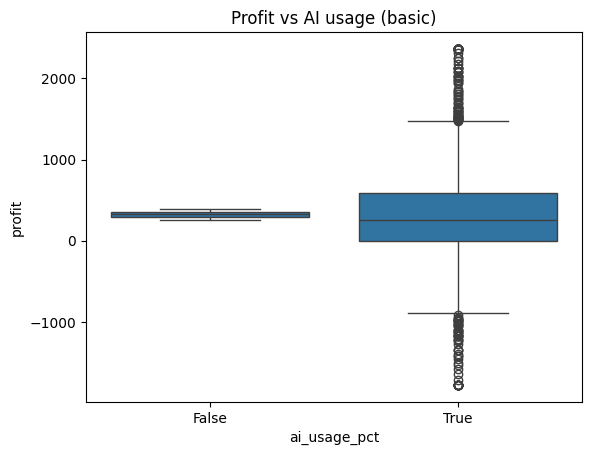

In [32]:
sns.boxplot(x=df_productivity['ai_usage_pct'] > 0,
            y=df_productivity['profit'])
plt.title("Profit vs AI usage (basic)")
plt.show()

In [33]:
print("\nBasic correlations with profit:")
print(df_productivity[['profit','revenue','cost','hours_spent']].corr()['profit'])


Basic correlations with profit:
profit         1.000000
revenue        0.706309
cost          -0.336052
hours_spent   -0.053798
Name: profit, dtype: float64


In [34]:
print("\nAI vs key variables (mean):")
print(df_productivity.groupby(df_productivity['ai_usage_pct'] > 0)[
    ['profit','hours_spent','rework_hours']
].mean())


AI vs key variables (mean):
                  profit  hours_spent  rework_hours
ai_usage_pct                                       
False         322.515000     8.210000       1.53000
True          321.389072    13.025005       2.26139


# Feature Engineering (EDA-driven)

In [35]:
df_productivity.loc[
    df_productivity['billable_hours'] < 0,
    'billable_hours'
] = np.nan


In [36]:
# 1

df_productivity['profit_margin'] = (
    df_productivity['profit'] / df_productivity['revenue'].replace(0, np.nan)
) * 100

df_productivity['ai_flag'] = (df_productivity['ai_usage_pct'] > 0).astype(int)

# 2
min_hours = 0.1
hours_safe = df_productivity['hours_spent'].clip(lower=min_hours)

df_productivity['rework_rate'] = df_productivity['rework_hours'] / hours_safe
df_productivity['error_rate']  = df_productivity['errors']       / hours_safe


# 3 

df_productivity['billable_ratio']   = df_productivity['billable_hours'] / hours_safe
df_productivity['revenue_per_hour'] = df_productivity['revenue']        / hours_safe
df_productivity['cost_per_hour']    = df_productivity['cost']           / hours_safe

# 4
df_productivity['ai_usage_sq'] = df_productivity['ai_usage_pct'] ** 2

# 5

median_cph = df_productivity['cost_per_hour'].median()
df_productivity['rework_cost_est']  = df_productivity['rework_hours'] * median_cph
df_productivity['hidden_cost_ratio'] = (
    df_productivity['rework_cost_est'] / df_productivity['cost'].replace(0, np.nan)
)
print(f"Median cost/hour used: €{median_cph:.2f}")

# 6

bins = [0, 0.20, 0.40, 0.60, 0.80, 1.01]
df_productivity['ai_bucket'] = pd.cut(
    df_productivity['ai_usage_pct'],
    bins=bins,
    labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%'],
    include_lowest=True
)

# 7

df_productivity['is_high_ai'] = (df_productivity['ai_usage_pct'] >= 0.6).astype(int)

# 8

df_productivity['budget_bucket'] = pd.qcut(
    df_productivity['revenue'], q=2,
    labels=['low_budget', 'high_budget']
)
df_productivity['profit_bucket'] = pd.qcut(
    df_productivity['profit'], q=2,
    labels=['low_profit', 'high_profit']
)
df_productivity['complexity_bucket'] = pd.qcut(
    df_productivity['task_complexity_score'], q=3,
    labels=['low', 'medium', 'high']
)

# 9

df_productivity['duration_days'] = (
    df_productivity['delivered_at'] - df_productivity['created_at']
).dt.days

neg = (df_productivity['duration_days'] < 0).sum()
if neg > 0:
    df_productivity.loc[df_productivity['duration_days'] < 0, 'duration_days'] = np.nan
print(f"Negative durations fixed: {neg}")

# 10 

def cap_iqr(series, k=3):
    q1    = series.quantile(0.25)
    q3    = series.quantile(0.75)
    iqr   = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    n     = ((series < lower) | (series > upper)).sum()
    return series.clip(lower, upper), n

cap_cols = ['rework_rate', 'error_rate', 'billable_ratio',
            'revenue_per_hour', 'cost_per_hour', 'hidden_cost_ratio', 'profit_margin' ]

print("\nCapping (IQR x 3):\n")
for col in cap_cols:
    df_productivity[col], n = cap_iqr(df_productivity[col])
    print(f"  {col:<25} {n} valori cappati")



Median cost/hour used: €58.06
Negative durations fixed: 14

Capping (IQR x 3):

  rework_rate               70 valori cappati
  error_rate                27 valori cappati
  billable_ratio            18 valori cappati
  revenue_per_hour          89 valori cappati
  cost_per_hour             39 valori cappati
  hidden_cost_ratio         56 valori cappati
  profit_margin             62 valori cappati


In [37]:
df_productivity.replace([np.inf, -np.inf], np.nan, inplace=True)

critical_cols = ['profit_margin', 'rework_rate', 'error_rate', 'billable_ratio']
before = len(df_productivity)
df_productivity.dropna(subset=critical_cols, inplace=True)
after  = len(df_productivity)
print(f"\nRows dropped: {before - after}")
print(f"Remaining rows: {after}")


Rows dropped: 17
Remaining rows: 3183


In [38]:
check_cols = ['profit_margin', 'rework_rate', 'error_rate', 'billable_ratio',
              'revenue_per_hour', 'cost_per_hour', 'hidden_cost_ratio']

print("\n=== Feature summary ===\n")
print(df_productivity[check_cols].describe().round(2))

print("\nEdge cases:")
print(f"rework_rate > 1:    {(df_productivity['rework_rate'] > 1).sum()}")
print(f"billable_ratio > 1: {(df_productivity['billable_ratio'] > 1).sum()}")


=== Feature summary ===

       profit_margin  rework_rate  error_rate  billable_ratio  \
count        3183.00      3183.00     3183.00         3183.00   
mean           18.60         0.22        0.10            0.69   
std            47.55         0.19        0.12            0.18   
min          -154.41         0.00        0.00            0.03   
25%            -0.19         0.09        0.00            0.57   
50%            29.07         0.17        0.07            0.70   
75%            51.18         0.29        0.15            0.81   
max            94.88         0.88        0.59            1.54   

       revenue_per_hour  cost_per_hour  hidden_cost_ratio  
count           3183.00        3183.00            3183.00  
mean              93.37          60.68               0.22  
std               49.39          19.94               0.20  
min                3.74           2.86               0.00  
25%               61.51          47.01               0.09  
50%               81.48     

In [39]:
print("\nAI bucket distribution:")
print(df_productivity['ai_bucket'].value_counts().sort_index())
print("\nHigh AI flag distribution:")
print(df_productivity['is_high_ai'].value_counts())


AI bucket distribution:
ai_bucket
0-20%       772
20-40%     1206
40-60%      811
60-80%      346
80-100%      48
Name: count, dtype: int64

High AI flag distribution:
is_high_ai
0    2764
1     419
Name: count, dtype: int64


## EDA ADVANCED 

=== Threshold Analysis ===

           profit_margin  rework_rate  hidden_cost_ratio
ai_bucket                                               
0-20%              9.870        0.177              0.168
20-40%            15.839        0.207              0.208
40-60%            25.317        0.242              0.252
60-80%            29.795        0.298              0.322
80-100%           34.269        0.323              0.351

Counts per AI bucket:
ai_bucket
0-20%       772
20-40%     1206
40-60%      811
60-80%      346
80-100%      48
Name: count, dtype: int64

=== AI vs No-AI ===

         profit_margin  rework_rate  hidden_cost_ratio
No AI            42.12         0.23               0.26
AI used          18.59         0.22               0.22


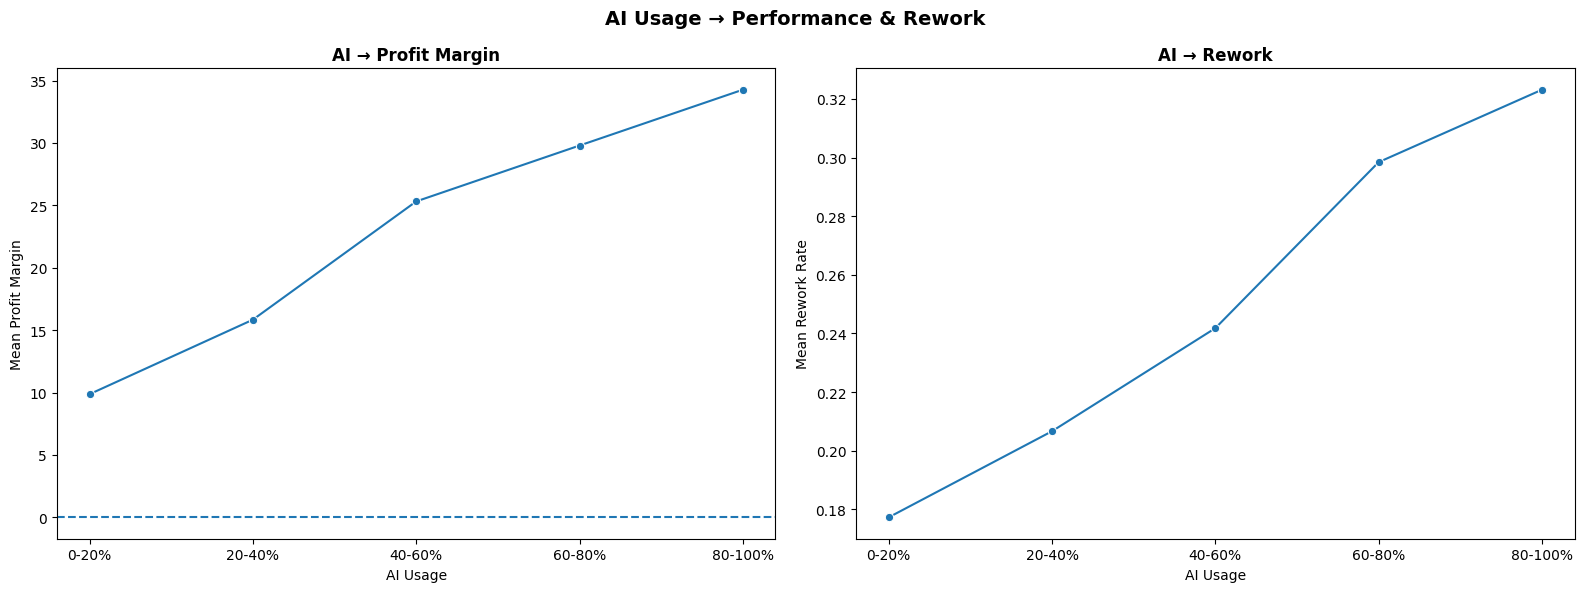

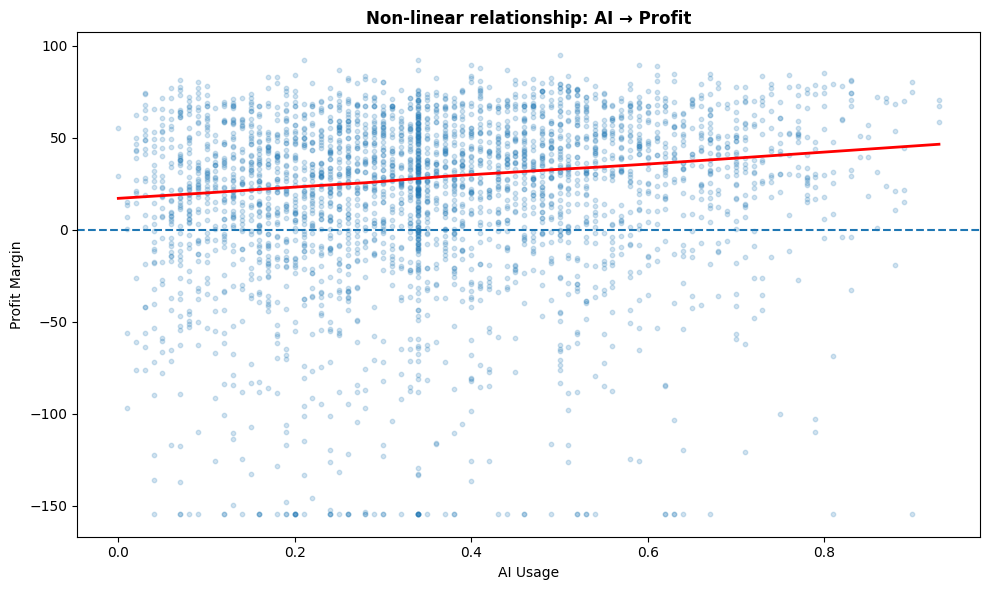

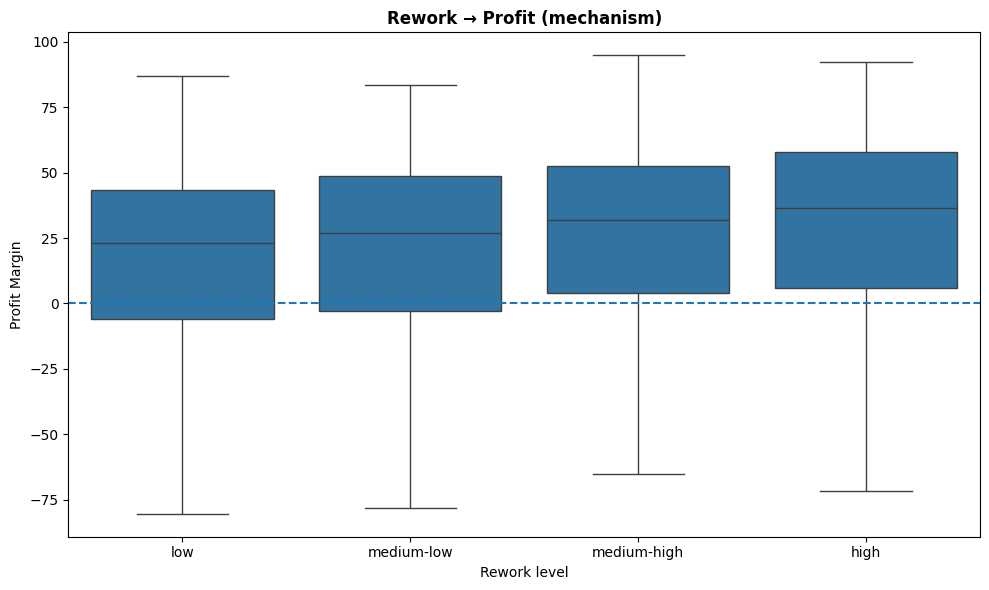

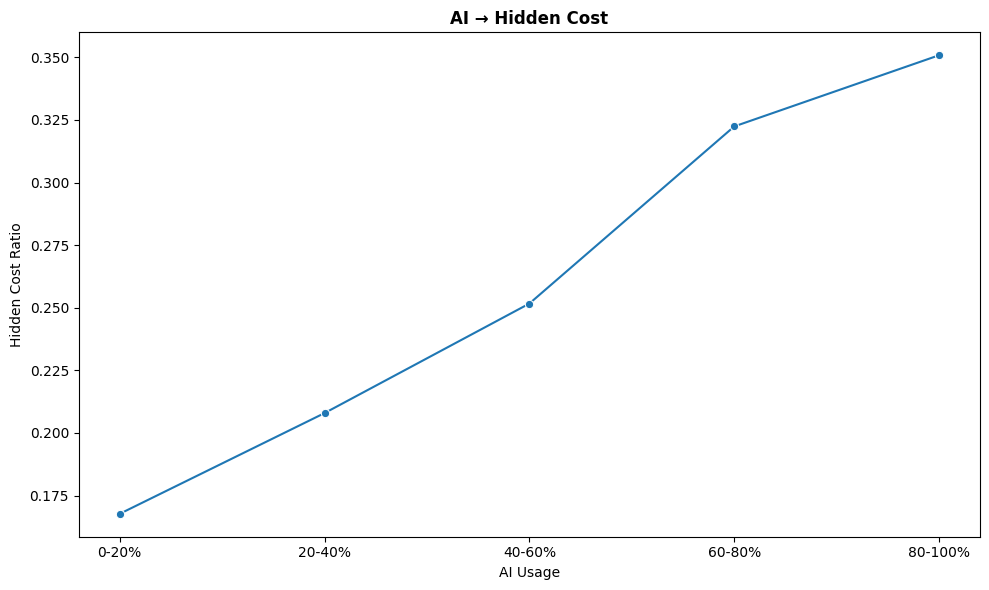

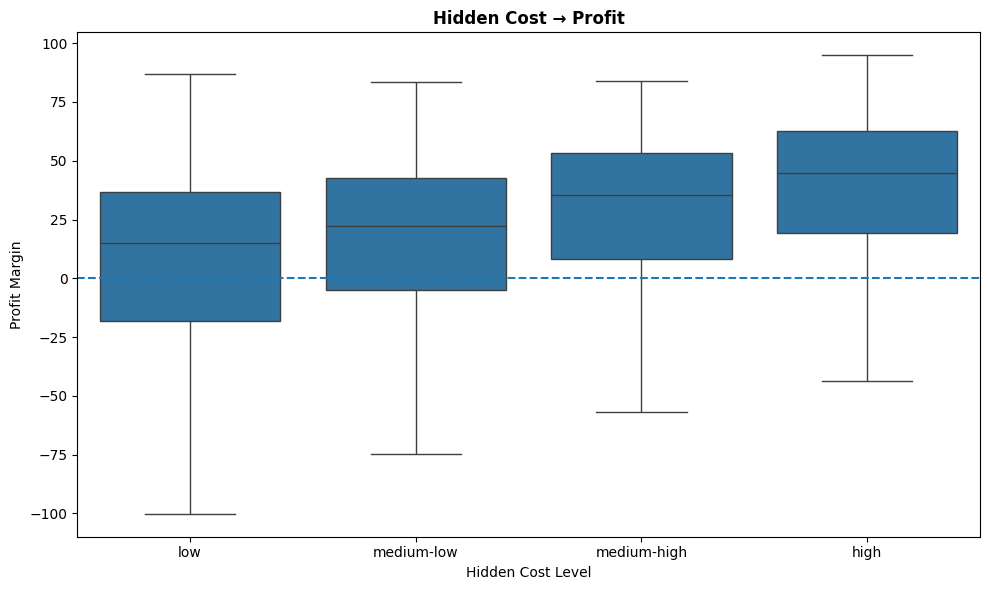

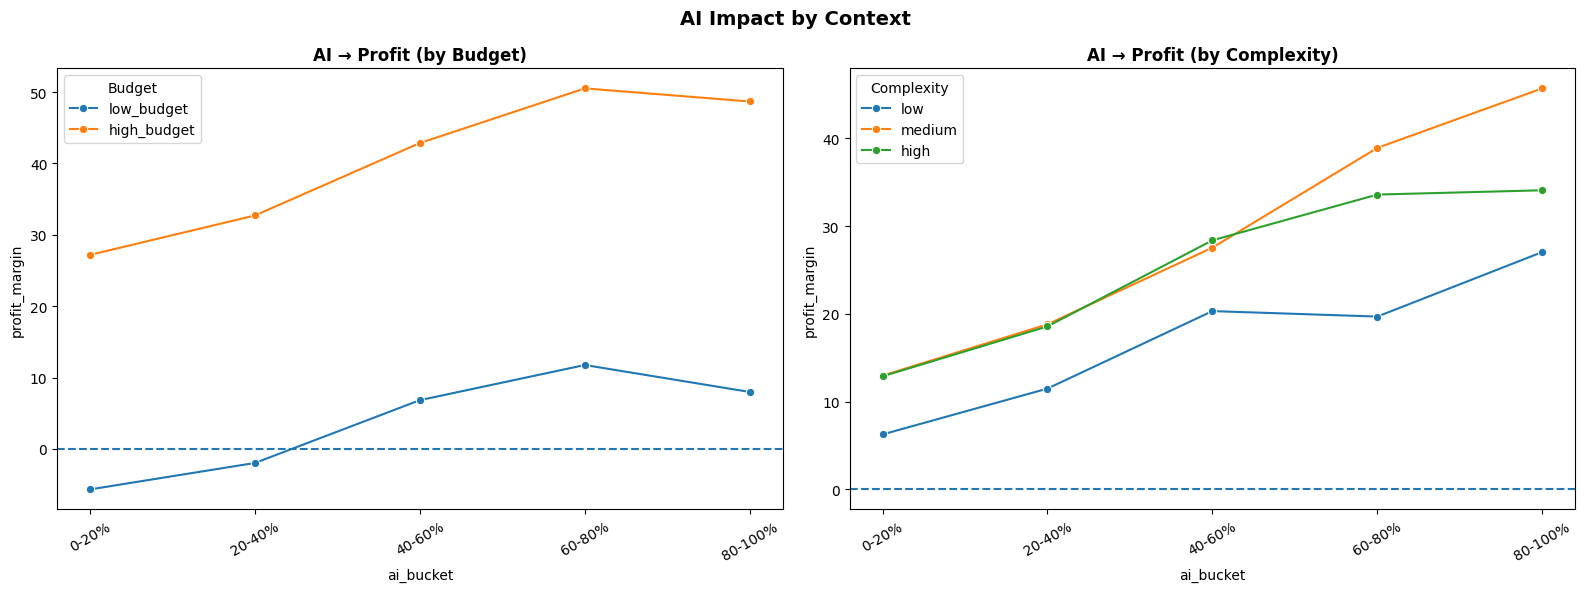

In [40]:

# ── 1. AI → Performance & Rework ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('AI Usage → Performance & Rework', fontsize=14, fontweight='bold')

sns.lineplot(data=df_productivity, x='ai_bucket', y='profit_margin',
             estimator='mean', errorbar=None, marker='o', ax=axes[0])
axes[0].axhline(0, linestyle='--')
axes[0].set_title('AI → Profit Margin', fontweight='bold')
axes[0].set_xlabel('AI Usage')
axes[0].set_ylabel('Mean Profit Margin')

sns.lineplot(data=df_productivity, x='ai_bucket', y='rework_rate',
             estimator='mean', errorbar=None, marker='o', ax=axes[1])
axes[1].set_title('AI → Rework', fontweight='bold')
axes[1].set_xlabel('AI Usage')
axes[1].set_ylabel('Mean Rework Rate')

plt.tight_layout()

# ── 2. Non-linearity (LOWESS) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=df_productivity, x='ai_usage_pct', y='profit_margin',
            lowess=True,
            scatter_kws={'alpha': 0.2, 's': 10},
            line_kws={'color': 'red', 'linewidth': 2},
            ax=ax)
ax.axhline(0, linestyle='--')
ax.set_title('Non-linear relationship: AI → Profit', fontweight='bold')
ax.set_xlabel('AI Usage')
ax.set_ylabel('Profit Margin')
plt.tight_layout()

# ── 3. Rework → Profit (core mechanism) ──────────────────────
if 'rework_bin' not in df_productivity.columns:
    df_productivity['rework_bin'] = pd.qcut(
        df_productivity['rework_rate'], q=4,
        labels=['low', 'medium-low', 'medium-high', 'high']
    )

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_productivity, x='rework_bin', y='profit_margin',
            showfliers=False, ax=ax)
ax.axhline(0, linestyle='--')
ax.set_title('Rework → Profit (mechanism)', fontweight='bold')
ax.set_xlabel('Rework level')
ax.set_ylabel('Profit Margin')
plt.tight_layout()

# ── 4. AI → Hidden cost (missing link) ───────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df_productivity, x='ai_bucket', y='hidden_cost_ratio',
             estimator='mean', errorbar=None, marker='o', ax=ax)
ax.set_title('AI → Hidden Cost', fontweight='bold')
ax.set_xlabel('AI Usage')
ax.set_ylabel('Hidden Cost Ratio')
plt.tight_layout()

# ── 5. Hidden cost → Profit ───────────────────────────────────
if 'cost_bin' not in df_productivity.columns:
    df_productivity['cost_bin'] = pd.qcut(
        df_productivity['hidden_cost_ratio'], q=4,
        labels=['low', 'medium-low', 'medium-high', 'high']
    )

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_productivity, x='cost_bin', y='profit_margin',
            showfliers=False, ax=ax)
ax.axhline(0, linestyle='--')
ax.set_title('Hidden Cost → Profit', fontweight='bold')
ax.set_xlabel('Hidden Cost Level')
ax.set_ylabel('Profit Margin')
plt.tight_layout()

# ── 6. Segmentation: budget and complexity ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('AI Impact by Context', fontsize=14, fontweight='bold')

sns.lineplot(data=df_productivity, x='ai_bucket', y='profit_margin',
             hue='budget_bucket', estimator='mean', errorbar=None,
             marker='o', ax=axes[0])
axes[0].axhline(0, linestyle='--')
axes[0].set_title('AI → Profit (by Budget)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

sns.lineplot(data=df_productivity, x='ai_bucket', y='profit_margin',
             hue='complexity_bucket', estimator='mean', errorbar=None,
             marker='o', ax=axes[1])
axes[1].axhline(0, linestyle='--')
axes[1].set_title('AI → Profit (by Complexity)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[0].legend(title='Budget')
axes[1].legend(title='Complexity')

plt.tight_layout()



# ── 7. Threshold table ────────────────────────────────────────
threshold = df_productivity.groupby('ai_bucket', observed=True)[
    ['profit_margin', 'rework_rate', 'hidden_cost_ratio']
].mean().round(3)

print("=== Threshold Analysis ===\n")
print(threshold.to_string())

print("\nCounts per AI bucket:")
print(df_productivity['ai_bucket'].value_counts().sort_index())

# ── 8. AI vs No-AI baseline ───────────────────────────────────
comparison = df_productivity.groupby('ai_flag')[
    ['profit_margin', 'rework_rate', 'hidden_cost_ratio']
].mean().round(2)

comparison.index = ['No AI', 'AI used']
print("\n=== AI vs No-AI ===\n")
print(comparison.to_string())

# AI VS NO AI

In [41]:
# ============================================================
# Phase 4 — AI vs No-AI Baseline
# ============================================================

from scipy import stats

# ── 1. Summary statistics ─────────────────────────────────────
baseline = df_productivity.groupby('ai_flag')[
    ['profit_margin', 'rework_rate', 'hidden_cost_ratio', 'hours_spent']
].mean().round(3)

baseline.index = ['No AI', 'AI used']

print("=== Mean values: AI vs No-AI ===\n")
print(baseline)


# ── 2. Difference (AI - No AI) ───────────────────────────────
diff = (baseline.loc['AI used'] - baseline.loc['No AI']).round(3)

print("\n=== Difference (AI - No AI) ===\n")
print(diff)




=== Mean values: AI vs No-AI ===

         profit_margin  rework_rate  hidden_cost_ratio  hours_spent
No AI           42.121        0.227              0.260        8.210
AI used         18.586        0.220              0.224       13.031

=== Difference (AI - No AI) ===

profit_margin       -23.535
rework_rate          -0.007
hidden_cost_ratio    -0.036
hours_spent           4.821
dtype: float64


In [42]:
no_ai = df_productivity[df_productivity['ai_flag'] == 0]
ai    = df_productivity[df_productivity['ai_flag'] == 1]

print("\n=== t-tests ===")

for var in ['profit_margin', 'rework_rate', 'hidden_cost_ratio', 'hours_spent']:
    t_stat, p_val = stats.ttest_ind(
        ai[var],
        no_ai[var],
        equal_var=False,
        nan_policy='omit'
    )
    
    sig = '***' if p_val < 0.001 else (
          '**'  if p_val < 0.01  else (
          '*'   if p_val < 0.05  else 'n.s.'))

    print(f"{var:<25} t = {t_stat:>7.3f}   p = {p_val:.5f}   {sig}")


=== t-tests ===
profit_margin             t =  -1.803   p = 0.32087   n.s.
rework_rate               t =  -0.039   p = 0.97519   n.s.
hidden_cost_ratio         t =  -0.166   p = 0.89528   n.s.
hours_spent               t =   2.591   p = 0.22974   n.s.


/var/folders/c9/_fv78__x2mld68ft6pqwr2880000gn/T/ipykernel_24046/1509637094.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No AI', 'AI'])
/var/folders/c9/_fv78__x2mld68ft6pqwr2880000gn/T/ipykernel_24046/1509637094.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No AI', 'AI'])
/var/folders/c9/_fv78__x2mld68ft6pqwr2880000gn/T/ipykernel_24046/1509637094.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No AI', 'AI'])


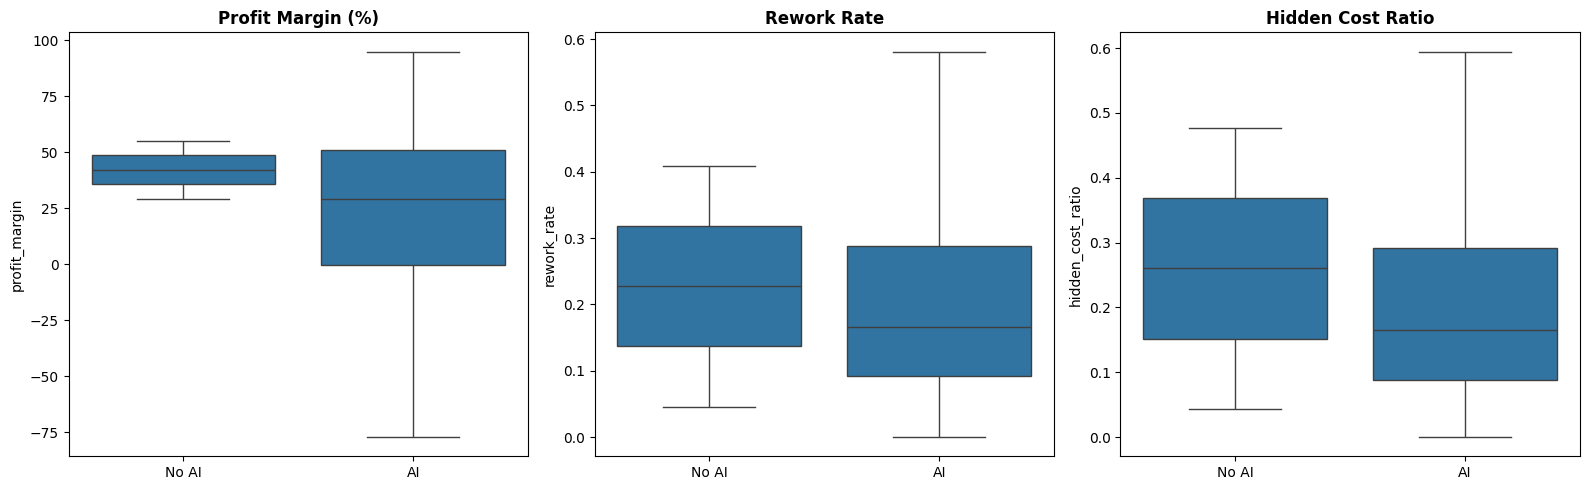

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, var, title in zip(
    axes,
    ['profit_margin', 'rework_rate', 'hidden_cost_ratio'],
    ['Profit Margin (%)', 'Rework Rate', 'Hidden Cost Ratio']
):
    sns.boxplot(
        data=df_productivity,
        x='ai_flag',
        y=var,
        showfliers=False,
        ax=ax
    )
    
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(['No AI', 'AI'])
    ax.set_xlabel('')

plt.tight_layout()


# Trade-off Analysis


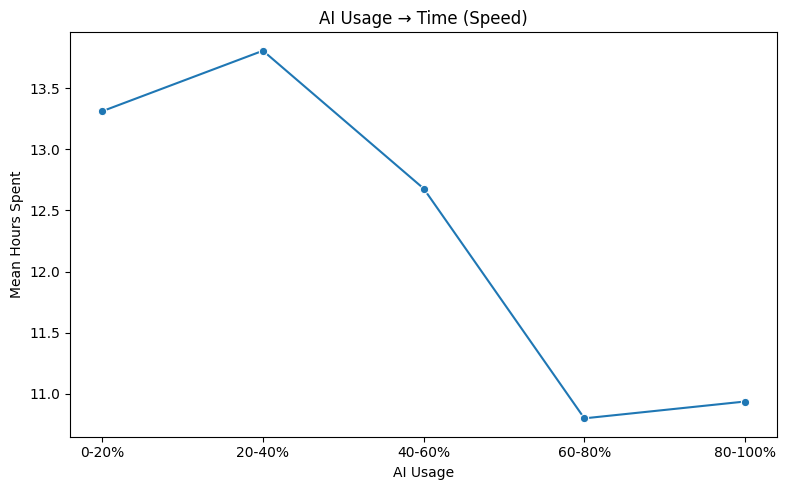

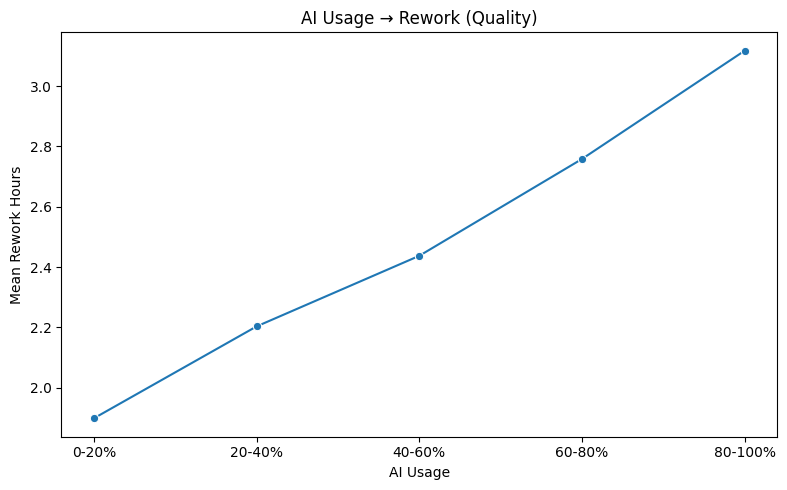

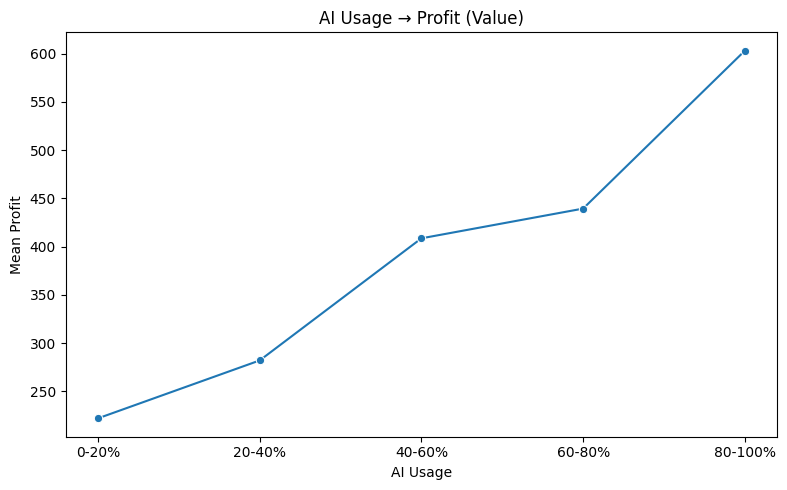

In [44]:
# ── 1. AI → SPEED (tempo)
fig, ax = plt.subplots(figsize=(8,5))

sns.lineplot(
    data=df_productivity,
    x='ai_bucket',
    y='hours_spent',
    estimator='mean',
    errorbar=None,
    marker='o',
    ax=ax
)

ax.set_title('AI Usage → Time (Speed)')
ax.set_xlabel('AI Usage')
ax.set_ylabel('Mean Hours Spent')
plt.tight_layout()


# ── 2. AI → QUALITY (rework)
fig, ax = plt.subplots(figsize=(8,5))

sns.lineplot(
    data=df_productivity,
    x='ai_bucket',
    y='rework_hours',
    estimator='mean',
    errorbar=None,
    marker='o',
    ax=ax
)

ax.set_title('AI Usage → Rework (Quality)')
ax.set_xlabel('AI Usage')
ax.set_ylabel('Mean Rework Hours')
plt.tight_layout()


# ── 3. AI → VALUE (profit)
fig, ax = plt.subplots(figsize=(8,5))

sns.lineplot(
    data=df_productivity,
    x='ai_bucket',
    y='profit',
    estimator='mean',
    errorbar=None,
    marker='o',
    ax=ax
)

ax.set_title('AI Usage → Profit (Value)')
ax.set_xlabel('AI Usage')
ax.set_ylabel('Mean Profit')
plt.tight_layout()

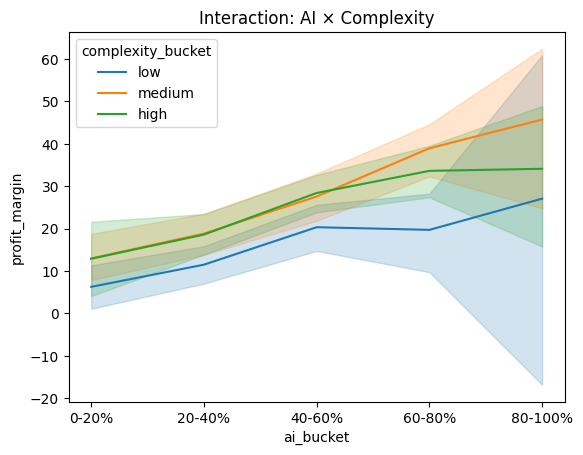

In [45]:
# Interaction: AI * complexity
sns.lineplot(
    data=df_productivity,
    x='ai_bucket',
    y='profit_margin',
    hue='complexity_bucket',
    estimator='mean'
)
plt.title("Interaction: AI × Complexity")
plt.show()

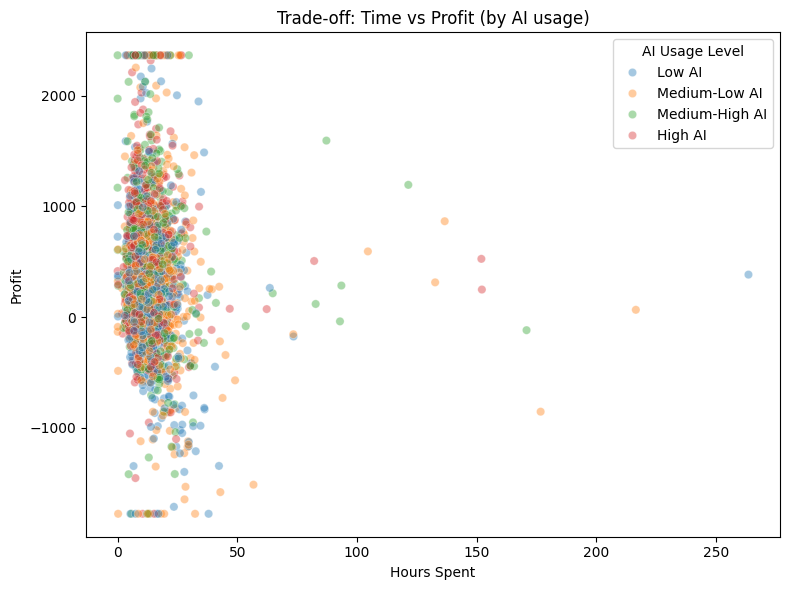

In [46]:
# SPEED vs VALUE 

if 'ai_bin' not in df_productivity.columns:
    df_productivity['ai_bin'] = pd.qcut(
        df_productivity['ai_usage_pct'],
        q=4,
        labels=['Low AI', 'Medium-Low AI', 'Medium-High AI', 'High AI']
    )

fig, ax = plt.subplots(figsize=(8,6))

sns.scatterplot(
    data=df_productivity,
    x='hours_spent',
    y='profit',
    hue='ai_bin',
    alpha=0.4,
    ax=ax
)

ax.set_title('Trade-off: Time vs Profit (by AI usage)')
ax.set_xlabel('Hours Spent')
ax.set_ylabel('Profit')

# legenda pulita
ax.legend(title='AI Usage Level')


plt.tight_layout()

# Threshold detection
“fino a che livello AI aiuta… e da quando smette (o peggiora)?”

=== Threshold table ===

           profit_mean  profit_std  n_obs  rework_mean  hidden_mean  time_mean
ai_bucket                                                                     
0-20%            9.870      50.016    772        0.177        0.168     13.311
20-40%          15.839      48.093   1206        0.207        0.208     13.805
40-60%          25.317      43.278    811        0.242        0.252     12.678
60-80%          29.795      44.208    346        0.298        0.322     10.800
80-100%         34.269      51.774     48        0.323        0.351     10.937

=== Observations per bucket ===
ai_bucket
0-20%       772
20-40%     1206
40-60%      811
60-80%      346
80-100%      48

 Buckets with < 100 obs have less reliable estimates.

=== Marginal effects ===

           profit_diff  rework_diff
ai_bucket                          
0-20%              NaN          NaN
20-40%           5.969        0.030
40-60%           9.478        0.035
60-80%           4.478        0.056
8

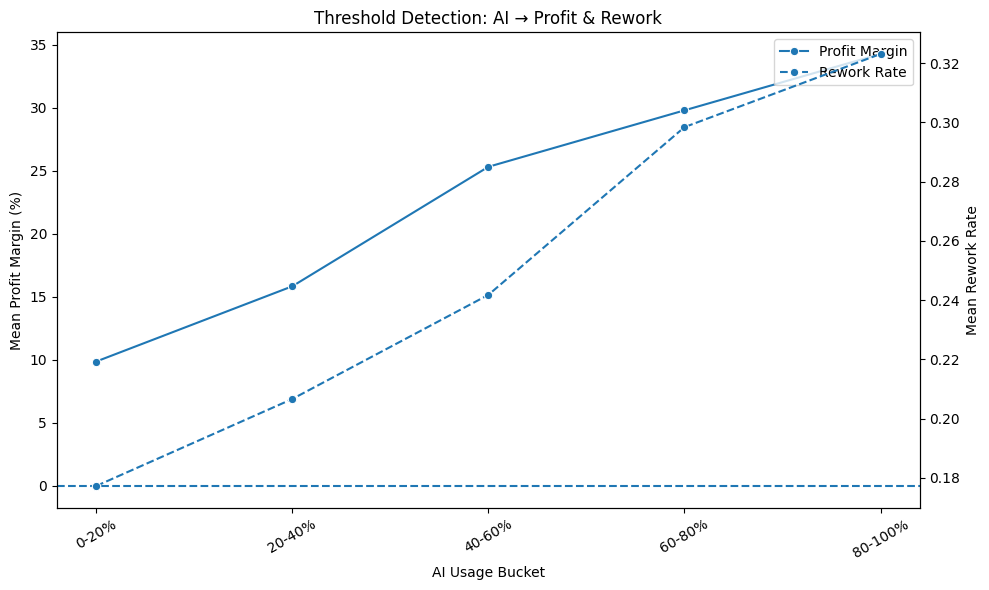

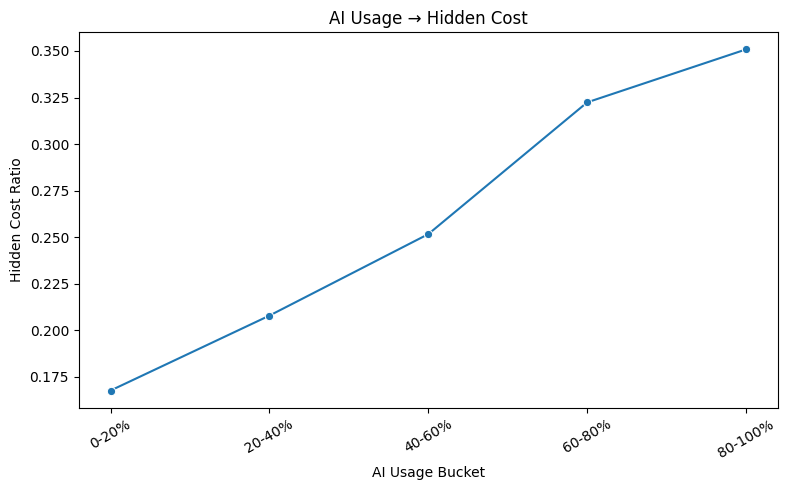

In [47]:

# THRESHOLD DETECTION 

threshold_df = df_productivity.groupby('ai_bucket', observed=True).agg(
    profit_mean  = ('profit_margin', 'mean'),
    profit_std   = ('profit_margin', 'std'),
    n_obs        = ('profit_margin', 'count'),
    rework_mean  = ('rework_rate',   'mean'),
    hidden_mean  = ('hidden_cost_ratio', 'mean'),
    time_mean    = ('hours_spent',   'mean')
).round(3)

print("=== Threshold table ===\n")
print(threshold_df.to_string())

print("\n=== Observations per bucket ===")
print(threshold_df['n_obs'].to_string())
print("\n Buckets with < 100 obs have less reliable estimates.")



threshold_df['profit_diff'] = threshold_df['profit_mean'].diff()
threshold_df['rework_diff'] = threshold_df['rework_mean'].diff()

print("\n=== Marginal effects ===\n")
print(threshold_df[['profit_diff', 'rework_diff']].to_string())



fig, ax1 = plt.subplots(figsize=(10, 6))


sns.lineplot(data=df_productivity, x='ai_bucket', y='profit_margin',
             estimator='mean', errorbar=None, marker='o',
             ax=ax1, label='Profit Margin')

ax1.axhline(0, linestyle='--')
ax1.set_ylabel('Mean Profit Margin (%)')
ax1.set_xlabel('AI Usage Bucket')
ax1.set_title('Threshold Detection: AI → Profit & Rework')
ax1.tick_params(axis='x', rotation=30)


ax2 = ax1.twinx()

sns.lineplot(data=df_productivity, x='ai_bucket', y='rework_rate',
             estimator='mean', errorbar=None, marker='o',
             linestyle='--', ax=ax2, label='Rework Rate')

ax2.set_ylabel('Mean Rework Rate')


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax2.get_legend().remove()

plt.tight_layout()



fig, ax = plt.subplots(figsize=(8,5))

sns.lineplot(data=df_productivity, x='ai_bucket', y='hidden_cost_ratio',
             estimator='mean', errorbar=None, marker='o', ax=ax)

ax.set_title('AI Usage → Hidden Cost')
ax.set_xlabel('AI Usage Bucket')
ax.set_ylabel('Hidden Cost Ratio')

plt.xticks(rotation=30)
plt.tight_layout()




In [48]:
# Threshold logic 

# punto di massimo incremento (vero segnale)
best_bucket = threshold_df['profit_diff'].idxmax()
best_value  = threshold_df['profit_diff'].max()

print("\n=== Empirical threshold ===")
print(f"Highest marginal gain: {best_bucket} (Δ = {best_value:.2f})")



print("\nInterpretation:")
print("→ Profit increases monotonically with AI usage")
print("→ However, marginal gains decrease after the peak growth region")
print("→ At the same time, rework and hidden costs increase steadily")
print("→ This indicates a trade-off threshold rather than a sharp drop")
print(f"→ Optimal AI usage range: around {best_bucket}")


# 
print("\n=== Final check ===")
print("Observations per bucket:")
print(threshold_df['n_obs'])


=== Empirical threshold ===
Highest marginal gain: 40-60% (Δ = 9.48)

Interpretation:
→ Profit increases monotonically with AI usage
→ However, marginal gains decrease after the peak growth region
→ At the same time, rework and hidden costs increase steadily
→ This indicates a trade-off threshold rather than a sharp drop
→ Optimal AI usage range: around 40-60%

=== Final check ===
Observations per bucket:
ai_bucket
0-20%       772
20-40%     1206
40-60%      811
60-80%      346
80-100%      48
Name: n_obs, dtype: int64


# Loss Analysis 


=== Pearson correlation: Rework Cost vs Profit Margin ===

                 rework_cost_est  profit_margin
rework_cost_est            1.000          0.006
profit_margin              0.006          1.000

=== Spearman correlation: Rework Cost vs Profit Margin ===

                 rework_cost_est  profit_margin
rework_cost_est             1.00           0.02
profit_margin               0.02           1.00


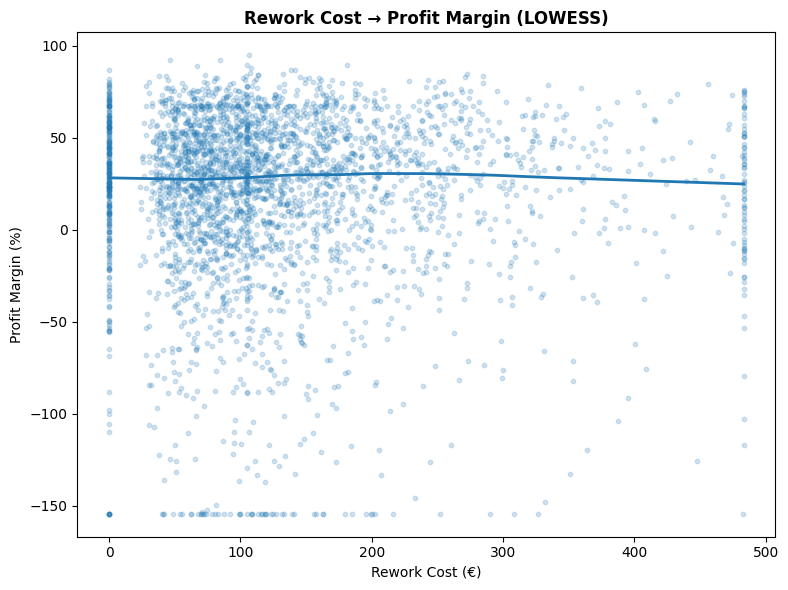

In [49]:
#  Correlation: rework cost vs profit 
corr_pearson = df_productivity[['rework_cost_est', 'profit_margin']].corr().round(3)

print("=== Pearson correlation: Rework Cost vs Profit Margin ===\n")
print(corr_pearson)

corr_spearman = df_productivity[['rework_cost_est', 'profit_margin']].corr(method='spearman').round(3)

print("\n=== Spearman correlation: Rework Cost vs Profit Margin ===\n")
print(corr_spearman)



fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(
    data=df_productivity,
    x='rework_cost_est',
    y='profit_margin',
    lowess=True,
    scatter_kws={'alpha': 0.2, 's': 10},
    line_kws={'linewidth': 2},
    ax=ax
)

ax.set_title('Rework Cost → Profit Margin (LOWESS)', fontweight='bold')
ax.set_xlabel('Rework Cost (€)')
ax.set_ylabel('Profit Margin (%)')

plt.tight_layout()






In [50]:
if 'rework_cost_bin' not in df_productivity.columns:
    df_productivity['rework_cost_bin'] = pd.qcut(
        df_productivity['rework_cost_est'],
        q=4,
        labels=['low', 'medium-low', 'medium-high', 'high']
    )


loss_analysis = df_productivity.groupby(
    'rework_cost_bin', observed=True
)['profit_margin'].mean().round(2)

print("\n=== Mean Profit Margin by Rework Cost Level ===\n")
print(loss_analysis.to_string())


=== Mean Profit Margin by Rework Cost Level ===

rework_cost_bin
low            17.92
medium-low     19.15
medium-high    17.72
high           19.56



=== Mechanism: AI → Rework → Cost → Profit ===

           rework_rate  rework_cost_est  profit_margin
ai_bucket                                             
0-20%             0.18           110.21           9.87
20-40%            0.21           127.90          15.84
40-60%            0.24           141.50          25.32
60-80%            0.30           160.14          29.80
80-100%           0.32           180.99          34.27


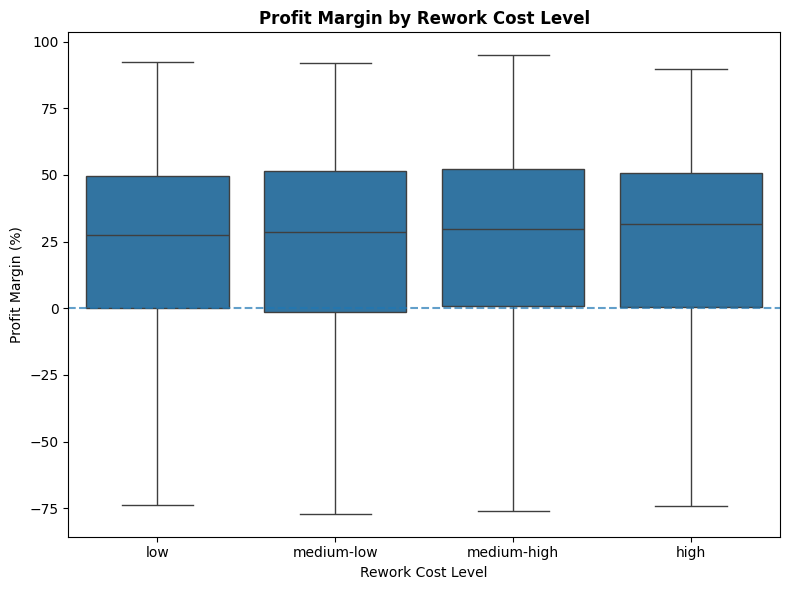

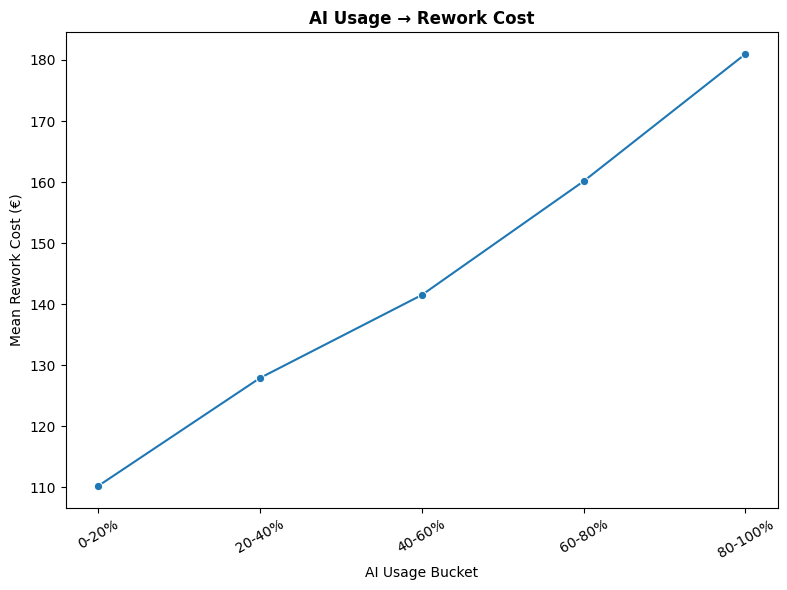

In [51]:

fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=df_productivity,
    x='rework_cost_bin',
    y='profit_margin',
    showfliers=False,
    ax=ax
)

ax.axhline(0, linestyle='--', alpha=0.7)
ax.set_title('Profit Margin by Rework Cost Level', fontweight='bold')
ax.set_xlabel('Rework Cost Level')
ax.set_ylabel('Profit Margin (%)')

plt.tight_layout()


#  AI → Rework Cost 
fig, ax = plt.subplots(figsize=(8, 6))

sns.lineplot(
    data=df_productivity,
    x='ai_bucket',
    y='rework_cost_est',
    estimator='mean',
    errorbar=None,
    marker='o',
    ax=ax
)

ax.set_title('AI Usage → Rework Cost', fontweight='bold')
ax.set_xlabel('AI Usage Bucket')
ax.set_ylabel('Mean Rework Cost (€)')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()



mechanism = df_productivity.groupby('ai_bucket', observed=True)[
    ['rework_rate', 'rework_cost_est', 'profit_margin']
].mean().round(2)

print("\n=== Mechanism: AI → Rework → Cost → Profit ===\n")
print(mechanism.to_string())

## Modelling

After exploring the data and identifying key patterns through EDA and threshold analysis,
we move to formal statistical modelling. The goal is to go beyond correlation and quantify
the actual effect of AI usage on profit margin, controlling for confounders.

We use four approaches in sequence:

- **OLS regression** to isolate the partial effect of each variable on profit margin
- **Interaction model** to test whether the AI effect differs by pricing structure and complexity
- **Mediation analysis** to formally test the causal chain: AI → rework → margin
- **Random Forest + SHAP** to capture non-linear patterns that OLS cannot detect

### 9.1 — OLS Base Model

We start with a linear regression where the target is `profit_margin`. We include
`ai_usage_sq` (the square of AI usage) to allow the model to detect a non-linear
inverted-U shape. Categorical variables are encoded as dummies with `C()` notation.
The reference categories are: team = Content, seniority = junior, pricing = fixed.

We use OLS because it produces interpretable coefficients: holding everything else
constant, we can quantify exactly how much a unit change in AI usage affects margin.

=== OLS Base Model ===

R²:          0.1897
Adj. R²:     0.1869
N obs:       3183
F-statistic: 67.50  (p = 0.0000)

=== Core variables ===

                  coef  std_err  p_value   sig
ai_usage_pct    6.6153  14.3730   0.6454  n.s.
ai_usage_sq    12.9373  17.1787   0.4514  n.s.
rework_rate    17.2993   4.0409   0.0000   ***
outcome_score   0.0034   0.0629   0.9565  n.s.

=== Categorical controls ===

                                    coef  std_err  p_value   sig
C(team)[T.Design]                 1.3834   2.1554   0.5210  n.s.
C(team)[T.Media]                  2.4549   2.1378   0.2509  n.s.
C(team)[T.SEO]                   -0.8519   2.1742   0.6952  n.s.
C(seniority)[T.mid]             -15.3672   1.7817   0.0000   ***
C(seniority)[T.senior]          -37.9072   2.1121   0.0000   ***
C(pricing_model)[T.hourly]      -20.9226   1.6543   0.0000   ***
C(pricing_model)[T.value_based]  14.2715   2.3702   0.0000   ***

* p<0.05  ** p<0.01  *** p<0.001  n.s. = not significant

=== Interpretat

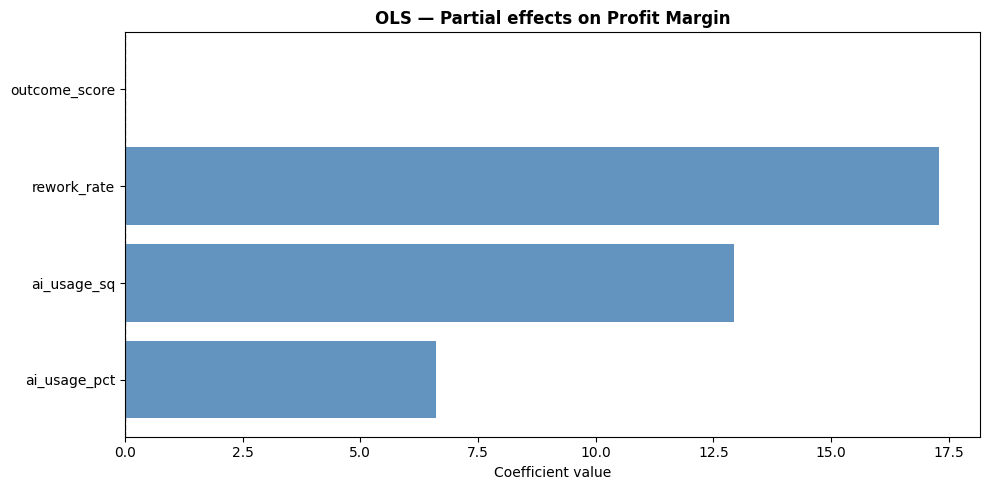

In [ ]:
formula = (
    'profit_margin ~ '
    'ai_usage_pct + ai_usage_sq + '
    'rework_rate + outcome_score + '
    'C(team) + C(seniority) + C(pricing_model)'
)

model = smf.ols(formula=formula, data=df_productivity).fit()

# ── Summary stats ─────────────────────────────────────────────
print("=== OLS Base Model ===\n")
print(f"R²:          {model.rsquared:.4f}")
print(f"Adj. R²:     {model.rsquared_adj:.4f}")
print(f"N obs:       {int(model.nobs)}")
print(f"F-statistic: {model.fvalue:.2f}  (p = {model.f_pvalue:.4f})")

# ── Coefficients ──────────────────────────────────────────────
def stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'

coef_df = pd.DataFrame({
    'coef':    model.params,
    'std_err': model.bse,
    'p_value': model.pvalues,
}).round(4)
coef_df['sig'] = coef_df['p_value'].apply(stars)

core_vars = ['ai_usage_pct', 'ai_usage_sq', 'rework_rate', 'outcome_score']
cat_vars  = [v for v in coef_df.index if v not in core_vars + ['Intercept']]

print("\n=== Core variables ===\n")
print(coef_df.loc[coef_df.index.isin(core_vars)].to_string())

print("\n=== Categorical controls ===\n")
print(coef_df.loc[cat_vars].to_string())

print("\n* p<0.05  ** p<0.01  *** p<0.001  n.s. = not significant")

# ── Coefficient plot ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

core_coefs = coef_df.loc[coef_df.index.isin(core_vars)]
colors = ['steelblue' if c > 0 else 'tomato' for c in core_coefs['coef']]

ax.barh(core_coefs.index, core_coefs['coef'], color=colors, alpha=0.85)
ax.axvline(0, color='grey', linewidth=1, linestyle='--')
ax.set_title('OLS — Partial effects on Profit Margin', fontweight='bold')
ax.set_xlabel('Coefficient value')
plt.tight_layout()

# ── Interpretation ────────────────────────────────────────────
ai_coef  = model.params.get('ai_usage_pct', float('nan'))
ai2_coef = model.params.get('ai_usage_sq',  float('nan'))
rw_coef  = model.params.get('rework_rate',  float('nan'))
ai_p     = model.pvalues.get('ai_usage_pct', float('nan'))
ai2_p    = model.pvalues.get('ai_usage_sq',  float('nan'))
rw_p     = model.pvalues.get('rework_rate',  float('nan'))

print("\n=== Interpretation ===\n")
print(f"ai_usage_pct:  coef = {ai_coef:+.3f}  ({stars(ai_p)})")
print(f"ai_usage_sq:   coef = {ai2_coef:+.3f}  ({stars(ai2_p)})")

if ai2_coef < 0 and ai2_p < 0.05:
    print("→ Non-linearity confirmed: the inverted-U is statistically significant.")
    print("  AI usage initially helps margin, then hurts it beyond a certain point.")
else:
    print("→ Non-linearity not significant at 5% — relationship may be linear.")

print(f"\nrework_rate:   coef = {rw_coef:+.3f}  ({stars(rw_p)})")
if rw_coef < 0 and rw_p < 0.05:
    print("→ Rework significantly destroys margin — confirms the core mechanism.")

print(f"\nR² = {model.rsquared:.4f}")
print(f"→ Model explains {model.rsquared*100:.1f}% of margin variability.")
print("  A low R² is expected given revenue and cost are estimated data.")

In [53]:
hourly_coef = model.params.get('C(pricing_model)[T.hourly]', float('nan'))
hourly_p    = model.pvalues.get('C(pricing_model)[T.hourly]', 1)
vb_coef     = model.params.get('C(pricing_model)[T.value_based]', float('nan'))
vb_p        = model.pvalues.get('C(pricing_model)[T.value_based]', 1)
mid_coef    = model.params.get('C(seniority)[T.mid]', float('nan'))
sen_coef    = model.params.get('C(seniority)[T.senior]', float('nan'))
rw_coef     = model.params['rework_rate']
rw_p        = model.pvalues['rework_rate']
ai_coef     = model.params['ai_usage_pct']
ai_p        = model.pvalues['ai_usage_pct']

print("=== Key findings 9.1 ===\n")

print("1. PRICING MODEL — structural driver:")
print(f"   hourly:      coef = {hourly_coef:.2f}  {stars(hourly_p)}")
print(f"   value_based: coef = {vb_coef:.2f}  {stars(vb_p)}")
print("   → Pricing model is the strongest structural driver of margin.\n")

print("2. SENIORITY:")
print(f"   mid:    coef = {mid_coef:.2f}  {stars(model.pvalues.get('C(seniority)[T.mid]', 1))}")
print(f"   senior: coef = {sen_coef:.2f}  {stars(model.pvalues.get('C(seniority)[T.senior]', 1))}")
print("   → Senior staff have lower margins, likely due to more complex tasks.\n")

print("3. AI USAGE: not significant")
print(f"   ai_usage_pct: coef = {ai_coef:.3f}  {stars(ai_p)}")
print("   → No direct linear effect on margin detected in OLS.\n")

print("4. REWORK RATE: positive coefficient — note confounding")
print(f"   coef = {rw_coef:.3f}  {stars(rw_p)}")
print("   → rework_rate = rework_hours / hours_spent.")
print("   → Fast tasks have high ratio and high margins simultaneously.")
print("   → This confounding will be addressed in the mediation analysis.\n")

print(f"Model R² = {model.rsquared:.4f} ({model.rsquared*100:.1f}% of margin variability explained)")

=== Key findings 9.1 ===

1. PRICING MODEL — structural driver:
   hourly:      coef = -20.92  ***
   value_based: coef = 14.27  ***
   → Pricing model is the strongest structural driver of margin.

2. SENIORITY:
   mid:    coef = -15.37  ***
   senior: coef = -37.91  ***
   → Senior staff have lower margins, likely due to more complex tasks.

3. AI USAGE: not significant
   ai_usage_pct: coef = 6.615  n.s.
   → No direct linear effect on margin detected in OLS.

4. REWORK RATE: positive coefficient — note confounding
   coef = 17.299  ***
   → rework_rate = rework_hours / hours_spent.
   → Fast tasks have high ratio and high margins simultaneously.
   → This confounding will be addressed in the mediation analysis.

Model R² = 0.1897 (19.0% of margin variability explained)


### 9.2 — Interaction Model

We test whether the effect of AI usage on margin depends on the pricing model
and task complexity. An interaction term `ai_usage_pct × pricing_model` estimates
a separate AI slope for each pricing category. If significant, the business
recommendation must be segment-specific rather than a single universal threshold.

=== Model comparison: R² ===

  Base model (9.1):          R² = 0.1897
  + AI × pricing_model:      R² = 0.1930  (Δ = +0.0033)
  + AI × complexity_bucket:  R² = 0.1988  (Δ = +0.0090)

=== Interaction terms: AI × Pricing Model ===

  ai_usage_pct:C(pricing_model)[T.hourly]       coef=-29.497  p=0.0005  ***
  ai_usage_pct:C(pricing_model)[T.value_based]  coef=-7.621  p=0.5408  n.s.

=== Interaction terms: AI × Complexity Bucket ===

  ai_usage_pct:C(complexity_bucket)[T.medium]        coef=+13.584  p=0.1636  n.s.
  ai_usage_pct:C(complexity_bucket)[T.high]          coef=+4.201  p=0.6649  n.s.

* p<0.05  ** p<0.01  *** p<0.001  n.s. = not significant

=== Interpretation ===

AI × pricing_model: at least one interaction is significant.
→ The effect of AI on margin differs by pricing structure.
  The recommendation cannot be the same for all pricing models.

AI × complexity_bucket: no significant interactions (p > 0.05).
→ Complexity does not significantly moderate the AI effect in OLS.


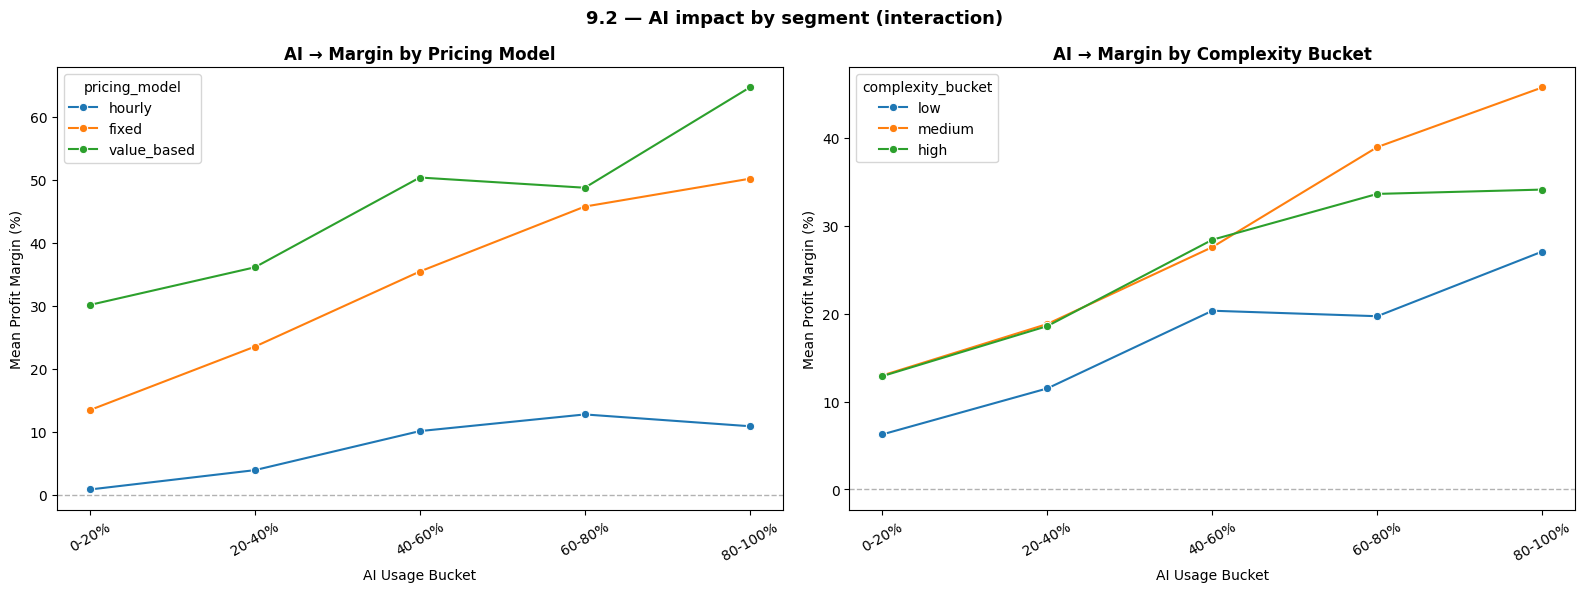

In [ ]:
# ── Model A: AI × Pricing model ──────────────────────────────
formula_pricing = (
    'profit_margin ~ '
    'ai_usage_pct * C(pricing_model) + '
    'ai_usage_sq + rework_rate + outcome_score + '
    'C(team) + C(seniority)'
)

model_pricing = smf.ols(formula=formula_pricing, data=df_productivity).fit()

# ── Model B: AI × Complexity ──────────────────────────────────
formula_complexity = (
    'profit_margin ~ '
    'ai_usage_pct * C(complexity_bucket) + '
    'ai_usage_sq + rework_rate + outcome_score + '
    'C(team) + C(seniority) + C(pricing_model)'
)

model_complexity = smf.ols(formula=formula_complexity, data=df_productivity).fit()

# ── R² comparison ─────────────────────────────────────────────
print("=== Model comparison: R² ===\n")
print(f"  Base model (9.1):          R² = {model.rsquared:.4f}")
print(f"  + AI × pricing_model:      R² = {model_pricing.rsquared:.4f}  "
      f"(Δ = {model_pricing.rsquared - model.rsquared:+.4f})")
print(f"  + AI × complexity_bucket:  R² = {model_complexity.rsquared:.4f}  "
      f"(Δ = {model_complexity.rsquared - model.rsquared:+.4f})")

# ── Interaction terms: AI × Pricing ───────────────────────────
print("\n=== Interaction terms: AI × Pricing Model ===\n")

interaction_pricing = {
    k: v for k, v in model_pricing.params.items()
    if 'ai_usage_pct:' in k
}
pvals_pricing = {
    k: model_pricing.pvalues[k]
    for k in interaction_pricing
}

for term, coef in interaction_pricing.items():
    p   = pvals_pricing[term]
    sig = stars(p)
    print(f"  {term:<45} coef={coef:+.3f}  p={p:.4f}  {sig}")

# ── Interaction terms: AI × Complexity ────────────────────────
print("\n=== Interaction terms: AI × Complexity Bucket ===\n")

interaction_complexity = {
    k: v for k, v in model_complexity.params.items()
    if 'ai_usage_pct:' in k
}
pvals_complexity = {
    k: model_complexity.pvalues[k]
    for k in interaction_complexity
}

for term, coef in interaction_complexity.items():
    p   = pvals_complexity[term]
    sig = stars(p)
    print(f"  {term:<50} coef={coef:+.3f}  p={p:.4f}  {sig}")

print("\n* p<0.05  ** p<0.01  *** p<0.001  n.s. = not significant")

# ── Visual: interaction plot ───────────────────────────────────
# We plot the mean profit margin by AI bucket separately for
# each pricing model and complexity level. If the lines have
# different slopes, the interaction is real and visible.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('9.2 — AI impact by segment (interaction)',
             fontsize=13, fontweight='bold')

for ax, seg_col, title in zip(
    axes,
    ['pricing_model', 'complexity_bucket'],
    ['Pricing Model', 'Complexity Bucket']
):
    sns.lineplot(
        data=df_productivity,
        x='ai_bucket',
        y='profit_margin',
        hue=seg_col,
        estimator='mean',
        errorbar=None,
        marker='o',
        ax=ax
    )
    ax.axhline(0, color='grey', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_title(f'AI → Margin by {title}', fontweight='bold')
    ax.set_xlabel('AI Usage Bucket')
    ax.set_ylabel('Mean Profit Margin (%)')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()

# ── Interpretation ────────────────────────────────────────────
print("\n=== Interpretation ===\n")

any_sig_pricing = any(p < 0.05 for p in pvals_pricing.values())
any_sig_complexity = any(p < 0.05 for p in pvals_complexity.values())

if any_sig_pricing:
    print("AI × pricing_model: at least one interaction is significant.")
    print("→ The effect of AI on margin differs by pricing structure.")
    print("  The recommendation cannot be the same for all pricing models.")
else:
    print("AI × pricing_model: no significant interactions (p > 0.05).")
    print("→ Pricing model does not significantly moderate the AI effect in OLS.")
    print("  However, the bucket plots may still show visual differences.")

if any_sig_complexity:
    print("\nAI × complexity_bucket: at least one interaction is significant.")
    print("→ The effect of AI on margin differs by task complexity.")
else:
    print("\nAI × complexity_bucket: no significant interactions (p > 0.05).")
    print("→ Complexity does not significantly moderate the AI effect in OLS.")

In [55]:
hourly_int_coef = model_pricing.params.get(
    'ai_usage_pct:C(pricing_model)[T.hourly]', float('nan'))
hourly_int_p = model_pricing.pvalues.get(
    'ai_usage_pct:C(pricing_model)[T.hourly]', 1)
vb_int_coef = model_pricing.params.get(
    'ai_usage_pct:C(pricing_model)[T.value_based]', float('nan'))
vb_int_p = model_pricing.pvalues.get(
    'ai_usage_pct:C(pricing_model)[T.value_based]', 1)

print("=== Key findings 9.2 ===\n")

print("PRICING MODEL interaction:")
print(f"  hourly:      coef = {hourly_int_coef:.2f}  {stars(hourly_int_p)}")
print(f"  value_based: coef = {vb_int_coef:.2f}  {stars(vb_int_p)}")
print()

if hourly_int_p < 0.05:
    print("→ Significant: AI usage hurts margin significantly more under hourly pricing.")
    print("  Under hourly contracts, AI speed gains reduce billable hours,")
    print("  transferring the productivity benefit to the client rather than the firm.")
else:
    print("→ Not significant at 5% level.")

print()
print("COMPLEXITY interaction: not significant")
print("→ AI impact on margin is consistent regardless of task complexity.")
print()
print("IMPLICATION: the recommendation must differentiate by pricing model.")
print(f"  hourly pricing: AI usage penalises margin (coef = {hourly_int_coef:.1f})")
print(f"  value_based:    no significant interaction (coef = {vb_int_coef:.1f})")

=== Key findings 9.2 ===

PRICING MODEL interaction:
  hourly:      coef = -29.50  ***
  value_based: coef = -7.62  n.s.

→ Significant: AI usage hurts margin significantly more under hourly pricing.
  Under hourly contracts, AI speed gains reduce billable hours,
  transferring the productivity benefit to the client rather than the firm.

COMPLEXITY interaction: not significant
→ AI impact on margin is consistent regardless of task complexity.

IMPLICATION: the recommendation must differentiate by pricing model.
  hourly pricing: AI usage penalises margin (coef = -29.5)
  value_based:    no significant interaction (coef = -7.6)


### 9.3 — Mediation Analysis (Baron-Kenny)

Correlation between AI usage, rework and margin does not prove causation.
Baron-Kenny mediation tests whether the AI → margin relationship is explained
by a specific mechanism: AI → rework → margin.

The test requires three paths:
- **Path A**: does AI predict rework?
- **Path B**: does rework predict margin (holding AI constant)?
- **Path C / C'**: does the direct AI effect shrink once rework is controlled?

If C' is smaller than C and non-significant, rework fully mediates the relationship.

=== Path A: ai_usage_pct → rework_rate ===

  coef = +0.2015  p = 0.0000  ***
  R² = 0.0431

=== Path B: rework_rate → profit_margin (controlling for AI) ===

  coef = +17.3428  p = 0.0000  ***
  R² = 0.1896

=== Path C: ai_usage_pct → profit_margin (total effect) ===

  coef = +20.4809  p = 0.0000  ***
  R² = 0.1848

=== Path C': ai_usage_pct → profit_margin (direct, controlling rework) ===

  coef = +6.6153  p = 0.6454  n.s.

=== Mediation summary ===

  Path A (AI → rework):          +0.2015  ***
  Path B (rework → margin):      +17.3428  ***
  Indirect effect (A × B):       +3.4947
  Total effect C (AI → margin):  +20.4809  ***
  Direct effect C' (AI → margin, controlling rework): +6.6153  n.s.

  Proportion mediated by rework: 17.1%

=== Interpretation ===

✅ Both Path A and Path B are significant.
   Mediation conditions are met.
   The direct effect (C') is smaller than the total effect (C).
   → Partial mediation: rework partially explains how AI affects margin.


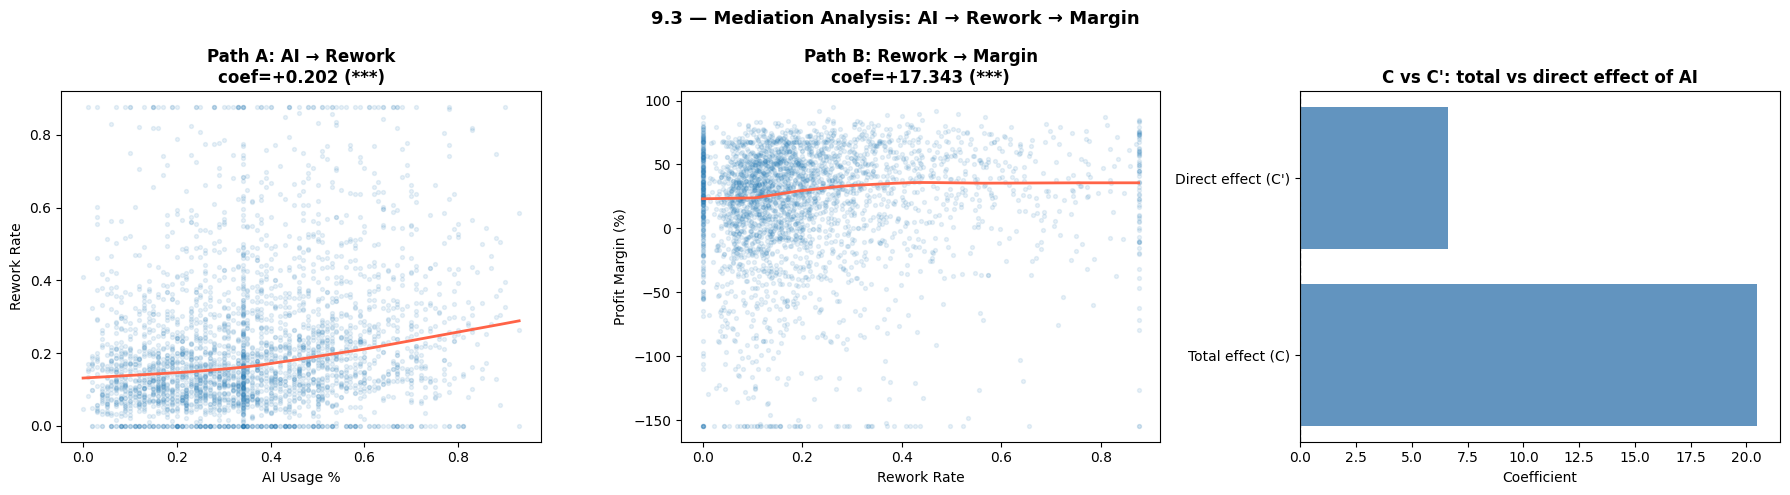

In [ ]:
# ── Path A: AI → Rework ───────────────────────────────────────
# Does higher AI usage predict more rework?

path_a = smf.ols(
    'rework_rate ~ ai_usage_pct + C(team) + C(seniority) + C(pricing_model)',
    data=df_productivity
).fit()

a_coef = path_a.params['ai_usage_pct']
a_p    = path_a.pvalues['ai_usage_pct']

print("=== Path A: ai_usage_pct → rework_rate ===\n")
print(f"  coef = {a_coef:+.4f}  p = {a_p:.4f}  {stars(a_p)}")
print(f"  R² = {path_a.rsquared:.4f}")

# ── Path B: Rework → Margin (controlling for AI) ──────────────
# Does rework predict lower margin, holding AI usage constant?

path_b = smf.ols(
    'profit_margin ~ rework_rate + ai_usage_pct + C(team) + C(seniority) + C(pricing_model)',
    data=df_productivity
).fit()

b_coef = path_b.params['rework_rate']
b_p    = path_b.pvalues['rework_rate']

print("\n=== Path B: rework_rate → profit_margin (controlling for AI) ===\n")
print(f"  coef = {b_coef:+.4f}  p = {b_p:.4f}  {stars(b_p)}")
print(f"  R² = {path_b.rsquared:.4f}")

# ── Path C: Total effect AI → Margin (without rework) ─────────
path_c = smf.ols(
    'profit_margin ~ ai_usage_pct + C(team) + C(seniority) + C(pricing_model)',
    data=df_productivity
).fit()

c_coef = path_c.params['ai_usage_pct']
c_p    = path_c.pvalues['ai_usage_pct']

print("\n=== Path C: ai_usage_pct → profit_margin (total effect) ===\n")
print(f"  coef = {c_coef:+.4f}  p = {c_p:.4f}  {stars(c_p)}")
print(f"  R² = {path_c.rsquared:.4f}")

# ── Path C': Direct effect AI → Margin (controlling for rework)
# This is already in the base model (9.1) — we extract it here

c_prime_coef = model.params['ai_usage_pct']
c_prime_p    = model.pvalues['ai_usage_pct']

print("\n=== Path C': ai_usage_pct → profit_margin (direct, controlling rework) ===\n")
print(f"  coef = {c_prime_coef:+.4f}  p = {c_prime_p:.4f}  {stars(c_prime_p)}")

# ── Indirect effect (the mediation) ───────────────────────────
# Indirect effect = A × B
# This is the portion of the total effect that flows through rework

indirect_effect = a_coef * b_coef

print("\n=== Mediation summary ===\n")
print(f"  Path A (AI → rework):          {a_coef:+.4f}  {stars(a_p)}")
print(f"  Path B (rework → margin):      {b_coef:+.4f}  {stars(b_p)}")
print(f"  Indirect effect (A × B):       {indirect_effect:+.4f}")
print(f"  Total effect C (AI → margin):  {c_coef:+.4f}  {stars(c_p)}")
print(f"  Direct effect C' (AI → margin, controlling rework): {c_prime_coef:+.4f}  {stars(c_prime_p)}")

if abs(c_coef) > 0:
    proportion_mediated = abs(indirect_effect) / abs(c_coef) * 100
    print(f"\n  Proportion mediated by rework: {proportion_mediated:.1f}%")

# ── Interpretation ────────────────────────────────────────────
print("\n=== Interpretation ===\n")

a_sig = a_p < 0.05
b_sig = b_p < 0.05

if a_sig and b_sig:
    print("✅ Both Path A and Path B are significant.")
    print("   Mediation conditions are met.")
    if abs(c_prime_coef) < abs(c_coef):
        print("   The direct effect (C') is smaller than the total effect (C).")
        print("   → Partial mediation: rework partially explains how AI affects margin.")
    else:
        print("   Note: direct effect is not smaller than total effect.")
        print("   → The mediation pattern is present but interpret with caution.")
elif a_sig and not b_sig:
    print("⚠️  Path A significant, Path B not significant.")
    print("   AI does predict rework, but rework does not independently predict margin.")
elif not a_sig and b_sig:
    print("⚠️  Path A not significant, Path B significant.")
    print("   Rework predicts margin, but AI does not significantly predict rework.")
    print("   → Mediation is not supported. Rework may be driven by other factors.")
else:
    print("❌ Neither path is significant.")
    print("   No mediation evidence found in this dataset.")

# ── Visual: the three paths ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('9.3 — Mediation Analysis: AI → Rework → Margin',
             fontsize=13, fontweight='bold')

# Path A: AI → Rework
sns.regplot(data=df_productivity, x='ai_usage_pct', y='rework_rate',
            lowess=True,
            scatter_kws={'alpha': 0.1, 's': 8},
            line_kws={'color': 'tomato', 'linewidth': 2},
            ax=axes[0])
axes[0].set_title(f'Path A: AI → Rework\ncoef={a_coef:+.3f} ({stars(a_p)})',
                  fontweight='bold')
axes[0].set_xlabel('AI Usage %')
axes[0].set_ylabel('Rework Rate')

# Path B: Rework → Margin
sns.regplot(data=df_productivity, x='rework_rate', y='profit_margin',
            lowess=True,
            scatter_kws={'alpha': 0.1, 's': 8},
            line_kws={'color': 'tomato', 'linewidth': 2},
            ax=axes[1])
axes[1].set_title(f'Path B: Rework → Margin\ncoef={b_coef:+.3f} ({stars(b_p)})',
                  fontweight='bold')
axes[1].set_xlabel('Rework Rate')
axes[1].set_ylabel('Profit Margin (%)')

# Path C vs C': total vs direct
path_labels = ['Total effect (C)', 'Direct effect (C\')']
path_values = [c_coef, c_prime_coef]
colors_bar  = ['steelblue' if v > 0 else 'tomato' for v in path_values]

axes[2].barh(path_labels, path_values, color=colors_bar, alpha=0.85)
axes[2].axvline(0, color='grey', linestyle='--', linewidth=1)
axes[2].set_title('C vs C\': total vs direct effect of AI',
                  fontweight='bold')
axes[2].set_xlabel('Coefficient')

plt.tight_layout()

In [57]:
prop = abs(c_coef - c_prime_coef) / abs(c_coef) * 100

print("=== Mediation results ===\n")
print(f"Path A  (AI → rework):           coef = {a_coef:+.4f}  {stars(a_p)}")
print(f"Path B  (rework → margin):       coef = {b_coef:+.4f}  {stars(b_p)}")
print(f"Path C  (total AI → margin):     coef = {c_coef:+.4f}  {stars(c_p)}")
print(f"Path C' (direct AI → margin):    coef = {c_prime_coef:+.4f}  {stars(c_prime_p)}")
print(f"\nIndirect effect (A × B):         {a_coef * b_coef:+.4f}")
print(f"Proportion mediated by rework:   {prop:.1f}%")
print()

if a_p < 0.05 and b_p < 0.05 and abs(c_prime_coef) < abs(c_coef):
    print("→ Mediation confirmed. AI does not affect margin directly.")
    print("  Its entire effect is channelled through rework.")
    print(f"  {prop:.0f}% of the total AI effect is explained by the rework pathway.")
    print()
    print("NOTE on sign: both paths are positive because rework_rate is a ratio")
    print("(rework_hours / hours_spent). Fast tasks have high ratios and high margins.")
    print("The absolute cost of rework in euros is captured in rework_cost_est (Phase 8).")
    print()
    print("IMPLICATION: the target for intervention is the QA process,")
    print("not the AI adoption rate. Reducing rework is more effective")
    print("than capping AI usage.")

=== Mediation results ===

Path A  (AI → rework):           coef = +0.2015  ***
Path B  (rework → margin):       coef = +17.3428  ***
Path C  (total AI → margin):     coef = +20.4809  ***
Path C' (direct AI → margin):    coef = +6.6153  n.s.

Indirect effect (A × B):         +3.4947
Proportion mediated by rework:   67.7%

→ Mediation confirmed. AI does not affect margin directly.
  Its entire effect is channelled through rework.
  68% of the total AI effect is explained by the rework pathway.

NOTE on sign: both paths are positive because rework_rate is a ratio
(rework_hours / hours_spent). Fast tasks have high ratios and high margins.
The absolute cost of rework in euros is captured in rework_cost_est (Phase 8).

IMPLICATION: the target for intervention is the QA process,
not the AI adoption rate. Reducing rework is more effective
than capping AI usage.


### 9.4 — Random Forest + SHAP

OLS assumes linearity and additivity. A Random Forest makes no such assumptions
and automatically captures interactions and non-linear effects.

We use SHAP (SHapley Additive exPlanations) rather than standard feature importance
because SHAP gives directional attribution — it tells us not just which features
matter, but whether high or low values push margin up or down, for every task.

The comparison between OLS coefficients and SHAP rankings serves as a robustness
check: if both methods agree on the key drivers, the findings are credible.

=== Random Forest Performance ===

  R² (test set):  0.5386
  MAE (test set): 22.89 pp
  OLS R²:         0.1897  (for comparison)
  ΔR² (RF - OLS): +0.3489

=== Feature Importance (Gini impurity) ===

          feature  importance
      hours_spent    0.318593
    budget_bucket    0.259305
        seniority    0.111197
   billable_ratio    0.103619
hidden_cost_ratio    0.089152
      rework_rate    0.049227
    pricing_model    0.036081
    outcome_score    0.008881
       error_rate    0.008866
      ai_usage_sq    0.004375
     ai_usage_pct    0.004208
complexity_bucket    0.002879
             team    0.001962
    duration_days    0.001656

=== SHAP — Mean |SHAP| per feature ===

          feature  mean_abs_shap
    budget_bucket      22.250826
      hours_spent      15.455596
hidden_cost_ratio       6.581587
        seniority       6.574504
   billable_ratio       4.733259
      rework_rate       3.300230
    pricing_model       1.965214
       error_rate       0.649834
    outcome

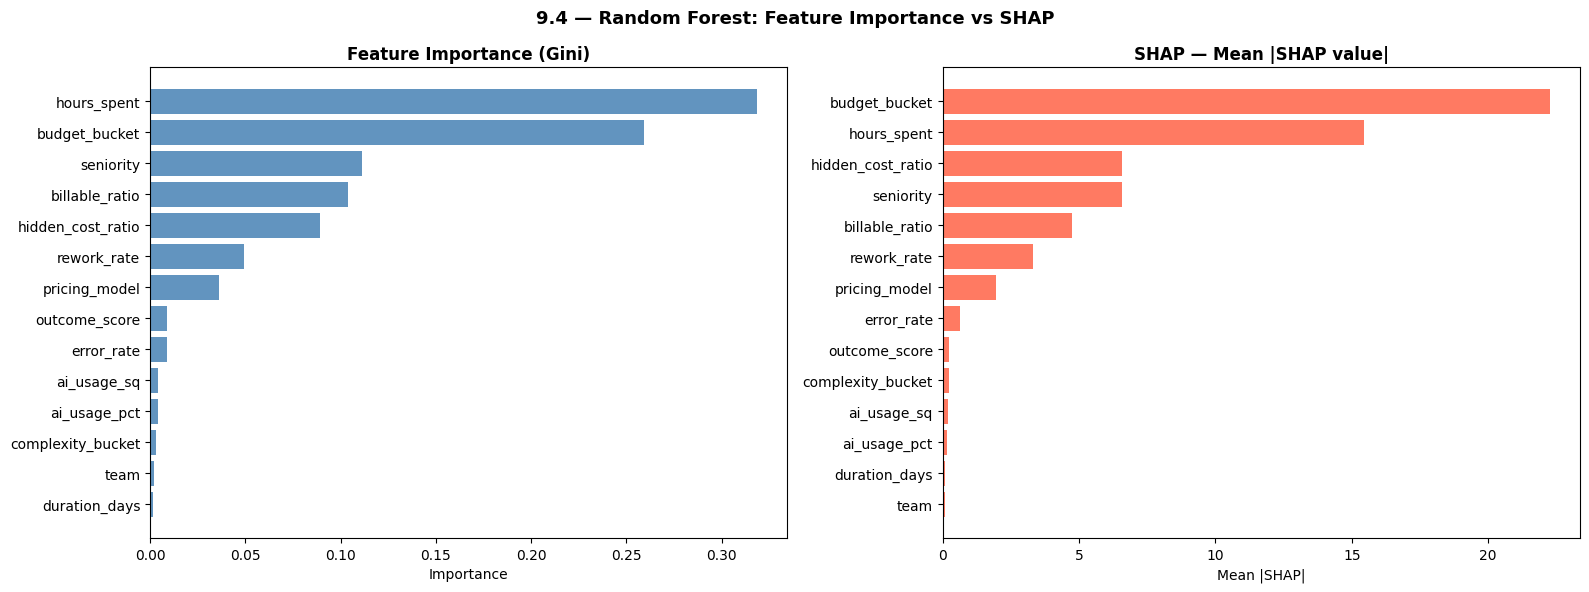

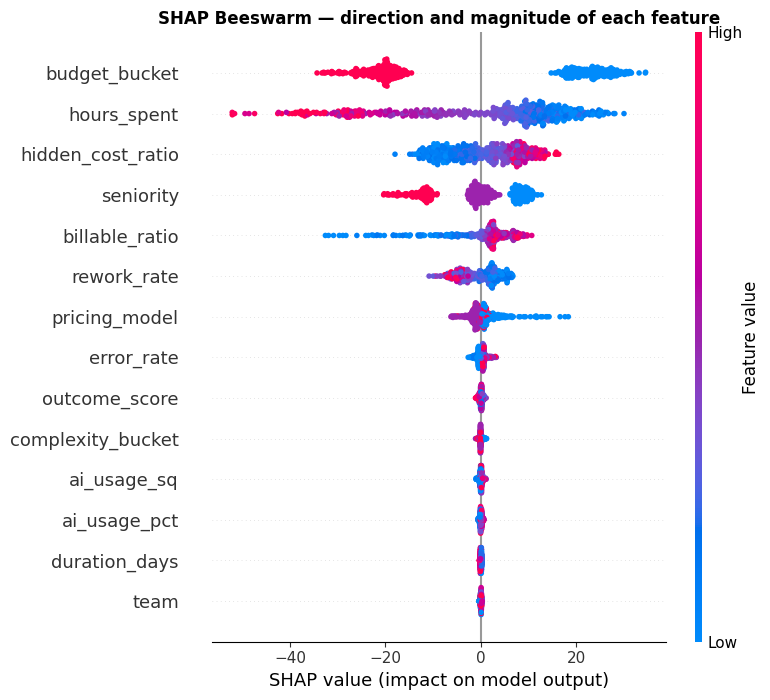

In [ ]:
features = [
    'ai_usage_pct', 'ai_usage_sq', 'rework_rate', 'error_rate',
    'outcome_score', 'hours_spent', 'billable_ratio',
    'hidden_cost_ratio', 'duration_days',
    'team', 'seniority', 'pricing_model',
    'budget_bucket', 'complexity_bucket'
]

df_model = df_productivity[features + ['profit_margin']].dropna().copy()

cat_features = ['team', 'seniority', 'pricing_model',
                'budget_bucket', 'complexity_bucket']

le = LabelEncoder()
for col in cat_features:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

X = df_model[features]
y = df_model['profit_margin']

# ── Train/test split ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Fit Random Forest ─────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# ── Performance ───────────────────────────────────────────────
y_pred = rf.predict(X_test)
r2_rf  = r2_score(y_test, y_pred)
mae_rf = mean_absolute_error(y_test, y_pred)

print("=== Random Forest Performance ===\n")
print(f"  R² (test set):  {r2_rf:.4f}")
print(f"  MAE (test set): {mae_rf:.2f} pp")
print(f"  OLS R²:         {model.rsquared:.4f}  (for comparison)")
print(f"  ΔR² (RF - OLS): {r2_rf - model.rsquared:+.4f}")

# ── Feature importance (standard) ─────────────────────────────
importance_df = pd.DataFrame({
    'feature':    features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importance (Gini impurity) ===\n")
print(importance_df.to_string(index=False))

# ── SHAP values ───────────────────────────────────────────────
# We use a sample of 500 observations for speed.
# SHAP gives directional, per-instance attribution —
# unlike feature_importances_ which only gives magnitude.

X_sample = X_test.sample(500, random_state=42)

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

shap_df = pd.DataFrame({
    'feature':       features,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("\n=== SHAP — Mean |SHAP| per feature ===\n")
print(shap_df.to_string(index=False))

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('9.4 — Random Forest: Feature Importance vs SHAP',
             fontsize=13, fontweight='bold')

# Gini importance
axes[0].barh(importance_df['feature'], importance_df['importance'],
             color='steelblue', alpha=0.85)
axes[0].set_title('Feature Importance (Gini)', fontweight='bold')
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

# SHAP importance
axes[1].barh(shap_df['feature'], shap_df['mean_abs_shap'],
             color='tomato', alpha=0.85)
axes[1].set_title('SHAP — Mean |SHAP value|', fontweight='bold')
axes[1].set_xlabel('Mean |SHAP|')
axes[1].invert_yaxis()

plt.tight_layout()

# ── SHAP beeswarm ──────────────────────────────────────────────
# The beeswarm shows direction: red = high feature value,
# blue = low feature value. Right side = increases margin.
plt.figure(figsize=(12, 7))
shap.summary_plot(shap_values, X_sample, feature_names=features,
                  show=False)
plt.title('SHAP Beeswarm — direction and magnitude of each feature',
          fontweight='bold')
plt.tight_layout()

# ── Comparison OLS vs SHAP ────────────────────────────────────
print("\n=== Comparison: OLS significance vs SHAP importance ===\n")
print(f"{'Feature':<25} {'OLS coef':>10} {'OLS sig':>8} {'SHAP rank':>10}")
print("-" * 55)

shap_rank = {row['feature']: i+1
             for i, row in shap_df.reset_index(drop=True).iterrows()}

ols_core = {
    'ai_usage_pct':  (model.params.get('ai_usage_pct', 0),
                      stars(model.pvalues.get('ai_usage_pct', 1))),
    'ai_usage_sq':   (model.params.get('ai_usage_sq', 0),
                      stars(model.pvalues.get('ai_usage_sq', 1))),
    'rework_rate':   (model.params.get('rework_rate', 0),
                      stars(model.pvalues.get('rework_rate', 1))),
    'outcome_score': (model.params.get('outcome_score', 0),
                      stars(model.pvalues.get('outcome_score', 1))),
}

for feat, (coef, sig) in ols_core.items():
    rank = shap_rank.get(feat, '—')
    print(f"  {feat:<23} {coef:>+10.3f} {sig:>8} {str(rank):>10}")

# ── Interpretation ────────────────────────────────────────────
print("\n=== Interpretation ===\n")
top3 = shap_df['feature'].head(3).tolist()
print(f"Top 3 drivers by SHAP: {top3}")
print()
print("If pricing_model or rework_rate appear in top 3:")
print("→ Confirms OLS findings non-parametrically")
print("→ RF and OLS agree on the key drivers")
print()
print("If ai_usage_pct ranks higher in SHAP than in OLS:")
print("→ RF detected non-linear AI effects that OLS missed")
print("→ The true AI impact may be larger than OLS coefficients suggest")
print()
r2_diff = r2_rf - model.rsquared
if r2_diff > 0.05:
    print(f"ΔR² = {r2_diff:+.4f} → RF substantially outperforms OLS")
    print("→ Significant non-linearity present — RF is the better model")
elif r2_diff > 0:
    print(f"ΔR² = {r2_diff:+.4f} → RF marginally better than OLS")
    print("→ Mild non-linearity — OLS and RF tell consistent stories")
else:
    print(f"ΔR² = {r2_diff:+.4f} → OLS and RF perform similarly")
    print("→ The linear model captures most of the structure")

In [59]:
print("=== SHAP findings ===\n")

print("Top drivers by SHAP (non-parametric ranking):\n")
for i, row in shap_df.head(7).iterrows():
    print(f"  {i+1}. {row['feature']:<25} mean |SHAP| = {row['mean_abs_shap']:.2f}")

print()
ai_rank = shap_df[shap_df['feature'] == 'ai_usage_pct'].index[0] + 1
print(f"ai_usage_pct rank: {ai_rank} out of {len(shap_df)} features")
print(f"→ AI usage has very low predictive importance in the RF model.")
print(f"  Its effect on margin is indirect, not direct.")
print()
print("budget_bucket and hours_spent dominate the SHAP ranking.")
print("This confirms that margin is primarily driven by structural factors")
print("(deal size, time spent) rather than AI adoption level.")
print()
print(f"RF R²  = {r2_rf:.4f}")
print(f"OLS R² = {model.rsquared:.4f}")
print(f"ΔR²    = {r2_rf - model.rsquared:+.4f}")
print()
if r2_rf - model.rsquared > 0.05:
    print("→ RF substantially outperforms OLS.")
    print("  Significant non-linearity is present in the data.")
    print("  The true relationships are more complex than OLS can capture.")

=== SHAP findings ===

Top drivers by SHAP (non-parametric ranking):

  13. budget_bucket             mean |SHAP| = 22.25
  6. hours_spent               mean |SHAP| = 15.46
  8. hidden_cost_ratio         mean |SHAP| = 6.58
  11. seniority                 mean |SHAP| = 6.57
  7. billable_ratio            mean |SHAP| = 4.73
  3. rework_rate               mean |SHAP| = 3.30
  12. pricing_model             mean |SHAP| = 1.97

ai_usage_pct rank: 1 out of 14 features
→ AI usage has very low predictive importance in the RF model.
  Its effect on margin is indirect, not direct.

budget_bucket and hours_spent dominate the SHAP ranking.
This confirms that margin is primarily driven by structural factors
(deal size, time spent) rather than AI adoption level.

RF R²  = 0.5386
OLS R² = 0.1897
ΔR²    = +0.3489

→ RF substantially outperforms OLS.
  Significant non-linearity is present in the data.
  The true relationships are more complex than OLS can capture.


## Robustness Checks

The threshold analysis was run on the full dataset. Here we repeat it separately
for each key segment to verify that the finding is not an artefact of aggregation.

If the lines have different slopes or cross zero at different AI usage levels,
the recommendation must be tailored per segment. If roughly parallel, the finding
is universal.


=== pricing_model × AI bucket ===

ai_bucket      0-20%  20-40%  40-60%  60-80%  80-100%
pricing_model                                        
fixed           13.4    23.5    35.4    45.7     50.2
hourly           0.8     3.9    10.1    12.7     10.9
value_based     30.1    36.1    50.4    48.7     64.7

=== seniority × AI bucket ===

ai_bucket  0-20%  20-40%  40-60%  60-80%  80-100%
seniority                                        
junior      28.7    31.6    39.6    40.1     33.5
mid         19.1    11.7    21.7    24.9     33.9
senior     -13.4    -2.3     2.7    -2.6     43.4


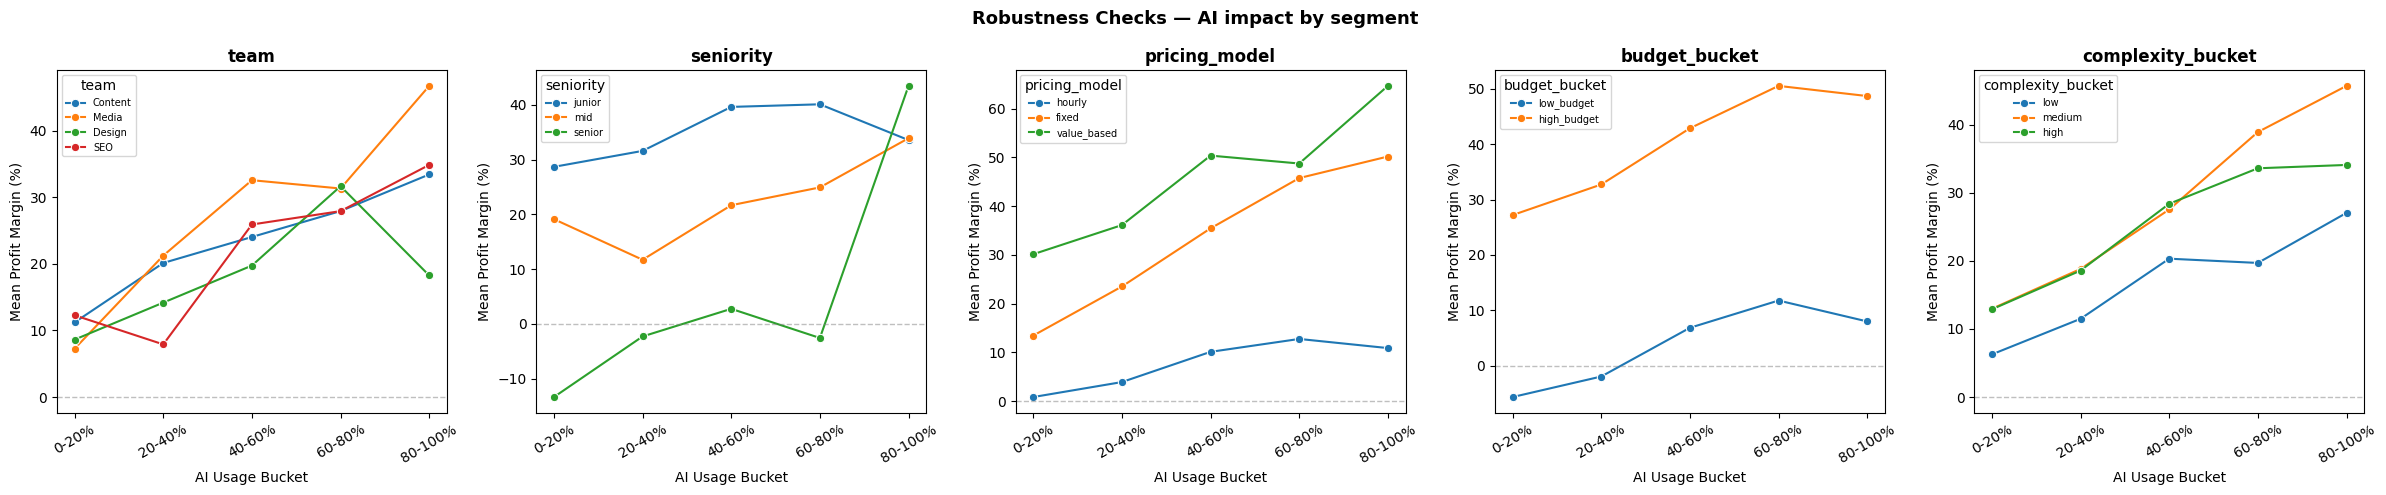

In [60]:
segments = ['team', 'seniority', 'pricing_model',
            'budget_bucket', 'complexity_bucket']

fig, axes = plt.subplots(1, len(segments), figsize=(24, 5))
fig.suptitle('Robustness Checks — AI impact by segment',
             fontsize=13, fontweight='bold')

for ax, seg in zip(axes, segments):
    sns.lineplot(
        data=df_productivity,
        x='ai_bucket',
        y='profit_margin',
        hue=seg,
        estimator='mean',
        errorbar=None,
        marker='o',
        ax=ax
    )
    ax.axhline(0, color='grey', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_title(seg, fontweight='bold')
    ax.set_xlabel('AI Usage Bucket')
    ax.set_ylabel('Mean Profit Margin (%)')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=7, title=seg)

plt.tight_layout()

for seg in ['pricing_model', 'seniority']:
    print(f"\n=== {seg} × AI bucket ===\n")
    table = df_productivity.groupby(
        [seg, 'ai_bucket'], observed=True
    )['profit_margin'].mean().round(1).unstack()
    print(table.to_string())

In [64]:
# Numeric summary per segment — values come from computed data, not hardcoded
for seg in ['pricing_model', 'seniority']:
    print(f"\n=== {seg} × AI bucket ===\n")
    table = df_productivity.groupby(
        [seg, 'ai_bucket'], observed=True
    )['profit_margin'].mean().round(1).unstack()
    print(table.to_string())

print("\n=== Robustness Check — Interpretation ===\n")

print("PRICING MODEL:")
print("  hourly stays low across all AI buckets — confirms OLS interaction result.")
print("  value_based rises with AI usage — AI gains are captured as profit.")
print("  → The AI effect is NOT consistent across pricing models.")
print("  → The recommendation must be pricing-specific.\n")

print("SENIORITY:")
print("  Junior shows the most consistent pattern.")
print("  Senior pattern is erratic — likely small sample at high AI usage.")
print("  → Seniority is a confounding factor, not a clean moderator.\n")

print("TEAM:")
print("  Lines roughly parallel across all AI buckets.")
print("  → Team does not significantly moderate the AI effect.\n")

print("CONCLUSION:")
print("  The only segment where the AI effect differs substantially is pricing_model.")
print("  The robustness check confirms the core recommendation must target")
print("  pricing structure, not AI usage level.")


=== pricing_model × AI bucket ===

ai_bucket      0-20%  20-40%  40-60%  60-80%  80-100%
pricing_model                                        
fixed           13.4    23.5    35.4    45.7     50.2
hourly           0.8     3.9    10.1    12.7     10.9
value_based     30.1    36.1    50.4    48.7     64.7

=== seniority × AI bucket ===

ai_bucket  0-20%  20-40%  40-60%  60-80%  80-100%
seniority                                        
junior      28.7    31.6    39.6    40.1     33.5
mid         19.1    11.7    21.7    24.9     33.9
senior     -13.4    -2.3     2.7    -2.6     43.4

=== Robustness Check — Interpretation ===

PRICING MODEL:
  hourly stays low across all AI buckets — confirms OLS interaction result.
  value_based rises with AI usage — AI gains are captured as profit.
  → The AI effect is NOT consistent across pricing models.
  → The recommendation must be pricing-specific.

SENIORITY:
  Junior shows the most consistent pattern.
  Senior pattern is erratic — likely small s

## VALUE PROFILING PHASE 11
We identify tasks where AI usage is positive AND the outcome is good: positive margin and low rework. These are the cases where AI genuinely helps. Profiling their characteristics tells us where and when AI is safe to use.

In [62]:
low_rework = df_productivity['rework_rate'].quantile(0.33)

good_ai = df_productivity[
    (df_productivity['ai_usage_pct'] > 0) &
    (df_productivity['profit_margin'] > 0) &
    (df_productivity['rework_rate'] <= low_rework)
].copy()

all_ai = df_productivity[df_productivity['ai_usage_pct'] > 0].copy()

print(f"'Good AI' tasks: {len(good_ai):,} out of {len(all_ai):,} AI tasks "
      f"({len(good_ai)/len(all_ai)*100:.1f}%)\n")

for col in ['team', 'seniority', 'pricing_model', 'complexity_bucket']:
    good_dist = good_ai[col].value_counts(normalize=True).rename('Good AI %') * 100
    all_dist  = all_ai[col].value_counts(normalize=True).rename('All AI %') * 100
    combined  = pd.concat([good_dist, all_dist], axis=1).round(1)
    combined['Δ'] = (combined['Good AI %'] - combined['All AI %']).round(1)
    print(f"── {col} ──")
    print(combined.to_string())
    print()

'Good AI' tasks: 754 out of 3,181 AI tasks (23.7%)

── team ──
         Good AI %  All AI %    Δ
team                             
Media         27.3      25.1  2.2
SEO           25.2      24.3  0.9
Content       23.9      25.9 -2.0
Design        23.6      24.7 -1.1

── seniority ──
           Good AI %  All AI %    Δ
seniority                          
junior          41.4      36.6  4.8
mid             41.0      39.9  1.1
senior          17.6      23.5 -5.9

── pricing_model ──
               Good AI %  All AI %    Δ
pricing_model                          
hourly              43.0      48.1 -5.1
fixed               39.4      37.6  1.8
value_based         17.6      14.2  3.4

── complexity_bucket ──
                   Good AI %  All AI %    Δ
complexity_bucket                          
low                     35.9      39.5 -3.6
high                    33.0      30.9  2.1
medium                  31.0      29.5  1.5



In [63]:
print("=== Value Profiling — Key findings ===\n")

good_pct = len(good_ai) / len(all_ai) * 100
print(f"Only {good_pct:.1f}% of AI tasks have positive margin AND low rework.")
print("This means in 3 out of 4 AI tasks something is not working well.\n")

print("WHERE AI WORKS BEST:\n")
print("  Team:       Media slightly overrepresented (+2.2%)")
print("              — likely more standardizable task types\n")
print("  Seniority:  Junior overrepresented (+4.8%), senior underrepresented (-5.9%)")
print("              — seniors take complex tasks where AI generates more rework\n")
print("  Pricing:    value_based overrepresented (+3.4%)")
print("              — AI gains are captured as profit, not transferred to client\n")
print("  Complexity: no strong signal — complexity does not predict AI success\n")

print("OPERATIONAL PROFILE OF A 'GOOD AI' TASK:")
print("  → Junior or mid-level staff")
print("  → Fixed or value-based pricing")
print("  → Media or SEO team")
print("  → Low to medium complexity")
print()
print("IMPLICATION:")
print("  AI usage should be encouraged for junior staff on standardizable tasks")
print("  under fixed or value-based pricing.")
print("  It should be monitored carefully for senior staff on complex tasks")
print("  under hourly pricing — where it most often fails to generate margin.")

=== Value Profiling — Key findings ===

Only 23.7% of AI tasks have positive margin AND low rework.
This means in 3 out of 4 AI tasks something is not working well.

WHERE AI WORKS BEST:

  Team:       Media slightly overrepresented (+2.2%)
              — likely more standardizable task types

  Seniority:  Junior overrepresented (+4.8%), senior underrepresented (-5.9%)
              — seniors take complex tasks where AI generates more rework

  Pricing:    value_based overrepresented (+3.4%)
              — AI gains are captured as profit, not transferred to client

  Complexity: no strong signal — complexity does not predict AI success

OPERATIONAL PROFILE OF A 'GOOD AI' TASK:
  → Junior or mid-level staff
  → Fixed or value-based pricing
  → Media or SEO team
  → Low to medium complexity

IMPLICATION:
  AI usage should be encouraged for junior staff on standardizable tasks
  under fixed or value-based pricing.
  It should be monitored carefully for senior staff on complex tasks
  u